# Generate final events set and figure panels

R notebook used to assemble manuscript diagrams for figures 2,3 and 4 from the summarized data generated by previous notebooks.

Short workflow:
  - load candidate events list, load per-tissue junction support and coverage data for case III events
  - load candidate events list, load per-tissue junction support and coverage data for case I and II events
  - join data for all cases
  - Filter by $\Delta\psi_1$ and $\Delta\tau$ and cor($\psi_1$, $\tau$) to identify events with tissue-specific isoform switch
    - filter events with $\Delta\psi_1 > 0.17$, $\Delta\tau >0.25$ and negative correlation between $\psi_1$ and $\tau$
    - plot $\psi_1$, $\tau$ panels for Supplementary figures 6 and 7
    - study how number of hits depend on the $\Delta\psi_1$ and $\Delta\tau$ thresholds (Supplementary figure 5)
    - plot Venn diagram for Figure 2B
    - save the hits list to `tissue_specific_hits.allcases.dtau025_qval01.n50.csv`  
  - load NMD inhibition data (from `CHX_data` folder)
    - the data includes psi and tau calculated for cells untreated/treated with CHX and psi and tau calculated from RIPiT experiments (reanalysed published datasets), all metrics were calculated for candidate events identified in `ATE-PE_from_PAS(IorII).ipynb` and `ATE-PE_from_novel_junc(III).ipynb` (451 events)
    - join data for cases I, II and III
    - identify poison exons that are upregulated upon NMD inhibition 
    - plot venn diagram for Figure 2C, SF8 
  - intersect list of events with tissue-specific isoform switch and poison exons that are upregulated upon NMD inhibition 
  - plot `Gviz` diagrams for selected examples

In [1]:
library(dplyr)
library(ggplot2)
library(stringr)
library(tidyr)
library(ggrepel)
library(latex2exp)

library(purrr) #map_dfr
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
dat_dir <- "."
pictures_dir <- "."

colors for GTEx tissues

In [ ]:
gtex_cols_raw <- read.table(
    "../references/GTEX_polyA/GTEX_SMTS_SMTSD_color_codes.tsv",
    sep = "\t", comment.char = "", header = TRUE, stringsAs = FALSE) #"/gss/mvlasenok/"

gtex_cols <- gtex_cols_raw %>%
    select(rcolor, SMTS) %>% unique() %>%
    group_by(SMTS) %>%
    summarise(rcolor = rcolor[1]) %>%
    mutate(
        SMTS = gsub(SMTS, pattern = " ", replacement = "_"),
        SMTS = gsub(x = SMTS, pattern = "Blood_Vessel", repl = "Artery"),
        SMTS = gsub(SMTS, pattern = "_Tissue", replacement = "")) %>%
    with(., setNames(as.character(rcolor), SMTS))

gtex_cols <- c(gtex_cols,
    Whole_Blood = "magenta",
    Bladder = "chocolate",
    Minor_Salivary_Gland = "wheat3",
    Spleen = "burlywood3",
    Small_Intestine = "peachpuff3",
    Cervix = "plum2")
gtex_smtsd <- gtex_cols_raw %>%
    select(SMTSD, rcolor, rcolor_brain) %>%
    mutate(
        SMTSD = gsub(x = SMTSD, pattern = " - ", replacement = "-"),
        SMTSD = gsub(x = SMTSD, pattern = " ", replacement = "_")) %>%
    with(., setNames(as.character(rcolor), SMTSD))
gtex_smtsd <- c(gtex_smtsd,
    "Colon-Sigmoid" = "burlywood2", Bladder = "chocolate",
    "Small_Intestine-Terminal_Ileum" = "burlywood3", Spleen = "burlywood3",
    "Cervix-Ectocervix" = "plum2", "Cervix-Endocervix" = "plum2",
    "Esophagus-Gastroesophageal_Junction" = "burlywood4", Minor_Salivary_Gland = "wheat3")

gtex_smtsd["Brain-Cerebellar_Hemisphere"] <- "yellow4"
gtex_smtsd["Brain-Cerebellum"] <- "yellow4"
gtex_cols["Cerebellum"] <- "yellow4"

In [4]:
theme_blank <- theme_bw() +
    theme(panel.grid = element_blank(),
        strip.background = element_rect(fill = NA))

# Figures from data from tissues

### tissue data for ATEPE from novel junc, case III

#### ATE from novel junc  load 

In [ ]:
nj_dat = "ATEPE_from_novel_junc_data/"

In [ ]:
ate <- read.table(paste0(nj_dat, "/novel_junc_ATEPE.n260.skip.tsv"), head = T, stringsAsFact = FALSE)

ate <- ate %>%
    mutate(
        chr = str_split_fixed(ex, pat = "_", n = 4)[, 1],
        strand = str_split_fixed(ex, pat = "_", n = 4)[, 4],
        ss1 = ifelse(strand == "+", str_split_fixed(E, pat = "_", n = 2)[ , 1], ss1.junc),
        ss4 = ifelse(strand == "+", ss4.junc, str_split_fixed(E, pat = "_", n = 2)[, 2]),
        ss2 = ifelse(strand == "+", str_split_fixed(ex, pat = "_", n = 4)[, 2], ss4.junc),
        ss3 = ifelse(strand == "+", ss1.junc, str_split_fixed(ex, pat = "_", n = 4)[, 3])) %>%
    mutate(
        I1 = paste(chr, ss1, ss2, strand, sep = "_"),
        I2 = paste(chr, ss3, ss4, strand, sep = "_"),
        E = paste(chr, ss1, ss4, strand, sep = "_"),
        ex = paste(chr, ss2, ss3, strand, ss1, ss4, sep = "_"),
        .keep = "unused")

#switch I1,I2 for - strand
ate <- ate %>%
    mutate(
        I1t = I1,
        I1 = ifelse(
            grepl(ex, pat = "+", fixed = T), I1, I2),
        I2 = ifelse(grepl(ex, pat = "+", fixed = T), I2, I1t)) %>%
    dplyr::select(-I1t)

add gene_name:

In [ ]:
gene_names <- read.table(
    "../references/chess3.1.3.GRCh38.prot_cod_trid-gene_name.tsv", stringsAsFactors = F,
    col.names = c("transcript_id", "gene_name"))
gene_names <- setNames(gene_names$gene_name, nm = gene_names$transcript_id)
ate <- ate %>%
    rowwise %>%
    mutate(tr_id1 = str_split(tr_id, pat = ",", simplify = T)[1]) %>%
    ungroup %>%
    mutate(gene_name = gene_names[tr_id1], .keep = "unused")

#### tissue data

Novel junc set. Load junction counts and coverage by tissue:

(created by "tissue_data_novel_junc(III).fin")

In [ ]:
load(file = paste0(nj_dat,"cov_junc_tis_nJ.novel_junc_ATEPE.n260.RData"))#cov_junc_tis_nJ

 plot distributions

In [16]:
cov_junc_exp_tis_plot <- cov_junc_tis_nJ %>% 
    filter(!grepl(tissue, pattern = "Cells")) %>% 
    group_by(ex, E_junc) %>% 
    filter(any(I1 + E > 10) & any(e1 > 0.2)) %>% 
    mutate(
        psi1 = ifelse(I1 + E > 10, I1 / (I1 + E), NA),
        psi2 = ifelse(I2 + E > 10, I2 / (I2 + E), NA),
        e2_e1 = ifelse(e1 > 0.2, e2 / e1, NA),
        n = sum(!is.na(e2_e1) & !is.na(psi1)),
        min_e2_e1 = min(e2_e1, na.rm = T),
        range_psi1 = max(psi1, na.rm = T) - min(psi1, na.rm = T),
        cor_psi_e2e1 = cor(e2_e1, psi1, method = "sp", use = "na.or.complete"),
        cor_psi_e2e1_pval = ifelse(sum(!is.na(e2_e1)) > 3,
                cor.test(e2_e1, psi1, method = "sp", altern = "less", use = "na.or.complete")$p.value, NA),
        #cor_tpm_e2e1=cor(e2_e1,tpm,method = "sp",use = "na.or.complete")) %>% 
        .groups = "drop") %>%
    mutate(cor_psi_e2e1_qval = p.adjust(cor_psi_e2e1_pval, method = "BH"))

Warning message:
“There were 167 warnings in `mutate()`.
The first warning was:
ℹ In argument: `cor_psi_e2e1 = cor(e2_e1, psi1, method = "sp", use = "na.or.complete")`.
ℹ In group 72: `ex = "chr14_49751010_49751145_+"`, `E_junc = "49743805_49751586"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 166 remaining warnings.”


In [ ]:
#plot psi1 and tau
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 150)
 ggplot(cov_junc_exp_tis_plot, aes(psi1))+geom_histogram(bins=50)+theme_blank
 ggplot(cov_junc_exp_tis_plot, aes(e2_e1)) + geom_histogram(bins=50)+theme_blank

### tissue data for ATEPE from PAS set, case I and II

load ATE-PE set from PAS. Load junction counts and coverage by tissue:

(created by "tissue_data_PAS.fin(IorII)")

In [ ]:
pas_dat = "ATEPE_from_PAS_data/"

In [ ]:
load(paste0(pas_dat, "cov_junc_exp_tis_filt.PEATE_allPAS.RData"))

# Join PAS and novel junc sets


In [59]:
cov_junc_tis_join <- rbind(
    cov_junc_exp_tis_filt %>% 
        select(-gene_id) %>% 
        unique %>%
        mutate(
            stop_cod = "-",
            reads = sum(I2),
            case = "caseIorII",
            .by = c(ex, E_junc, gene_name)),
    cov_junc_tis_nJ %>% 
        select(-c(within_ex, UTR_len, tr_id, ss1.ate, ss4.ate, ss1.junc, ss4.junc)) %>%
        unique %>%
        mutate(case = "caseIII", tpm = NA))

cov_junc_tis_join <- cov_junc_tis_join %>% 
    filter(!grepl(tissue, pattern = "Cells")) %>% 
    group_by(gene_name, ex, E_junc) %>% 
    filter(any(I1 + E > 10) & any(e1 > 0.2)) %>% 
    mutate(
        psi1 = ifelse(I1 + E > 10, I1 / (I1 + E), NA),
        psi2 = ifelse(E + I2 > 10, I2 / (E + I2), NA),
        e2_e1 = ifelse(e1 > 0.2, e2 / e1, NA),
        e2_e1 = ifelse(e2_e1 > 1, 1, e2_e1))

In [60]:
#remove duplicated exons in overlapping UGT1A genes, leaving UGT1A6 gene (the only such case)
cov_junc_tis_join <- cov_junc_tis_join %>% 
    filter(!(ex == "chr2_233769531_233769664_+" & (gene_name == "UGT1A10" | gene_name == "UGT1A7")))

## Panels filtered by dpsi and dtau

In [25]:
RANGE_PSI1 = 0.17
DE2E1_TIS = 0.248
COR_Q = 0.11

In [61]:
cov_junc_exp_tis_cor <- cov_junc_tis_join %>% 
    summarize(
        n = sum(!is.na(e2_e1) & !is.na(psi1)),
        min_e2e1 = min(e2_e1, na.rm = T),
        max_e2e1 = max(e2_e1, na.rm = T),
        range_psi1 = max(psi1, na.rm = T) - min(psi1, na.rm = T),
        cor_psi_e2e1 = cor(e2_e1, psi1, method = "sp", use = "na.or.complete"), #psi~pA <0
        cor_psi_e2e1_pval = ifelse(
            sum(!is.na(e2_e1)) > 3,
            cor.test(e2_e1, psi1, method = "sp", altern = "less", use = "na.or.complete")$p.value,
            NA),
        .groups = "drop") %>%
    mutate(
        cor_psi_e2e1_qval = p.adjust(cor_psi_e2e1_pval, method = "BH"),
        de2e1 = max_e2e1 - min_e2e1) %>%
        data.frame

Warning message:
“There were 521 warnings in `summarize()`.
The first warning was:
ℹ In argument: `cor_psi_e2e1 = cor(e2_e1, psi1, method = "sp", use = "na.or.complete")`.
ℹ In group 3: `gene_name = "ACOX3"`, `ex = "chr4_8386680_8388372_-"`, `E_junc = "8381607_8389173"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 520 remaining warnings.”


In [ ]:
#table with hits needs stop_codon, reads, case
gtex_filt_ST <- left_join(
    cov_junc_exp_tis_cor %>% 
        filter(
            range_psi1 > RANGE_PSI1,
            de2e1 > DE2E1_TIS,
            cor_psi_e2e1_qval < COR_Q),
    cov_junc_tis_join %>% 
        ungroup %>% 
        select(ex, E_junc, gene_name, stop_cod, reads, case) %>% 
        unique
    ) %>% 
    arrange(ex, E_junc) 
gtex_filt_ST %>% pull(gene_name)
#to file
#gtex_filt_ST %>% 
#    mutate(across(where(is.double), ~round(.x,2))) %>% 
#    rename(split_reads = reads) %>% 
#    arrange(gene_name) %>%  
#write.csv(file = "tissue_specific_hits.allcases.dtau025_qval01.n50.csv", row.names = F, quote = FALSE)

Joining with `by = join_by(gene_name, ex, E_junc)`


[1] 51 14

[1] "PDZD7"   "PDZD7"   "NMT2"    "NRP1"    "AKR1E2"  "PPP2R1B" "PITPNM2"
 [8] "ANKS1B"  "ANKS1B"  "TM2D3"   "TUBGCP5" "GCOM1"   "MEGF11"  "NPTN"   
[15] "CDK12"   "CDK12"   "RUNDC3A" "ARMC7"   "TPGS2"   "GCDH"    "FBXO27" 
[22] "HIF3A"   "VRK3"    "ZNF880"  "CFAP74"  "LEPR"    "THAP3"   "GCA"    
[29] "UGT1A6"  "LRRFIP1" "PRKCE"   "TMEM45A" "NECTIN3" "CCDC66"  "THAP6"  
[36] "THAP6"   "TRMT44"  "TRMT44"  "PWWP2A"  "BDP1"    "CCNH"    "WTAP"   
[43] "BTN2A2"  "CPED1"   "DDX31"   "NFX1"    "NFX1"    "TPM2"    "FXN"    
[50] "SEMA4D"  "MTMR1"

### Plot panels

In [36]:
cov_junc_exp_tis_plot <- left_join(
    cov_junc_exp_tis_cor %>%
        filter(
            range_psi1 > RANGE_PSI1,
            de2e1 > DE2E1_TIS,
            cor_psi_e2e1_qval < COR_Q) %>%
        unique,
    ungroup(cov_junc_tis_join)
) %>%

    mutate(
        ex = gsub(x = ex, pat = "_", rep = " "),
        gene = paste(gene_name, round(cor_psi_e2e1, digits = 3), sep = "| cor=")) %>%
    unique

Joining with `by = join_by(gene_name, ex, E_junc)`


In [37]:
cov_junc_exp_tis_plot %>%
    select(ex, E_junc, gene_name) %>%
    arrange(gene_name) %>% unique %>% dim

[1] 50  3

Warning message:
“Removed 469 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 469 rows containing missing values (`geom_point()`).”


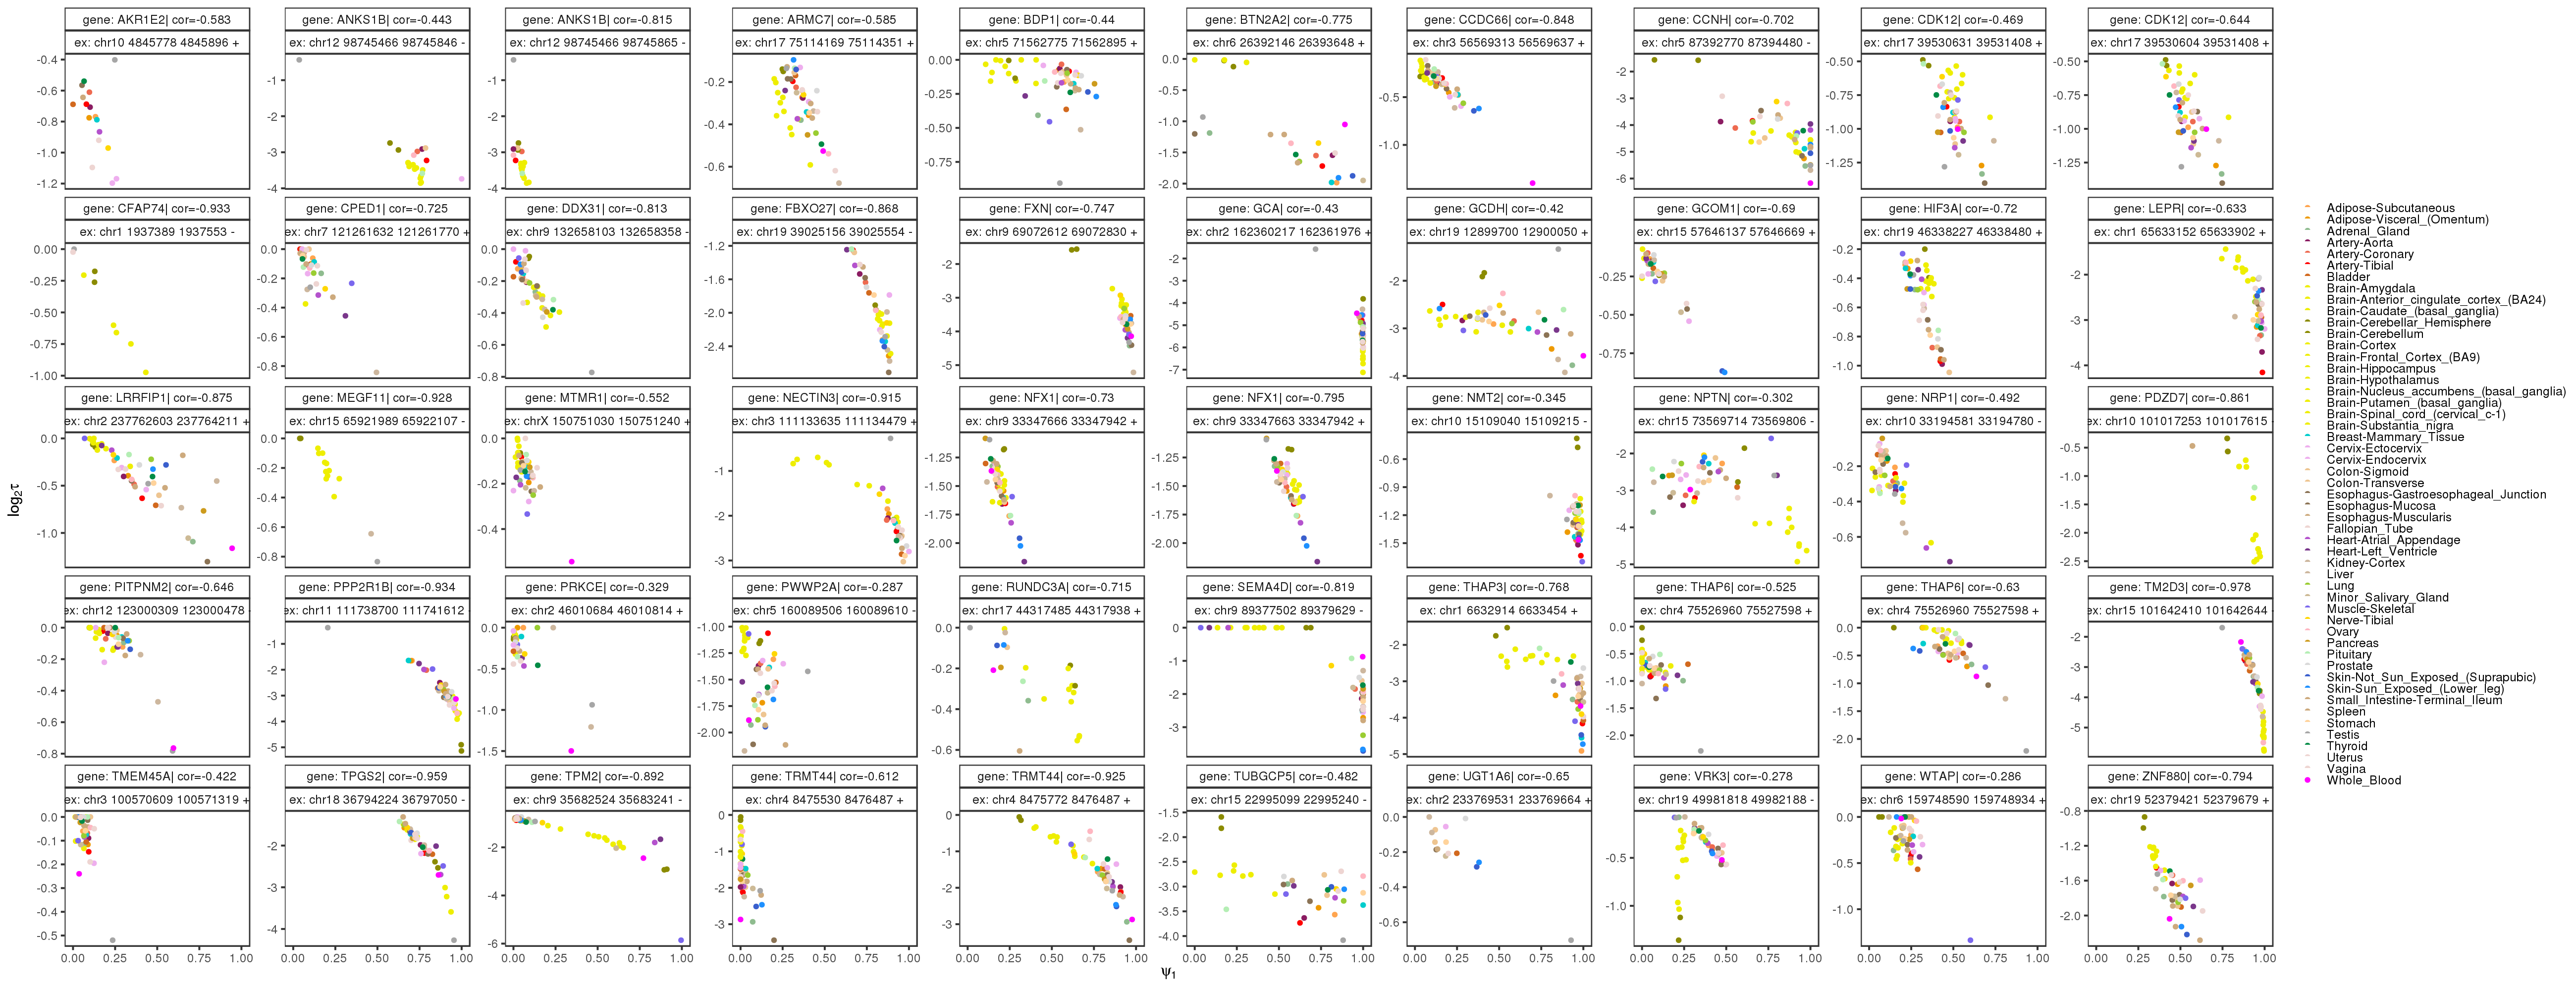

In [72]:
options(repr.plot.width = 26, repr.plot.height = 10, repr.plot.res = 200)

ggplot(cov_junc_exp_tis_plot, aes(x = psi1, y = log2(e2_e1), color = tissue)) +
    geom_point(size = 1) + #aes(size=log10(loc_exp)))+
    facet_wrap(. ~ gene + ex, scales = "free_y", nrow = 5, labeller = label_both) +
    #scale_y_continuous(trans= "log2",breaks = c(0,0.005,0.01,0.025,0.05,0.1,0.15,0.25,0.45,0.6,0.75,0.9,1,1.25,2))+
    scale_color_manual(values = gtex_smtsd) +
    ylab(TeX("$log_2 \\tau$")) +
    xlab(TeX("$\\psi_1$")) +
    theme_blank +
    theme(legend.position = "right",
        legend.title = element_blank(),
        legend.spacing.y = unit(-9, "pt")) +
    guides(colour = guide_legend(ncol = 1, byrow = TRUE))
ggsave(
    filename = "panel_psi1_e2e1.allcases.dtau025_qval01.n50_noUGTduplicates.pdf",
    device = "pdf", path = pictures_dir,
    width = 26, height = 10)

Warning message:
“Removed 343 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 343 rows containing missing values (`geom_point()`).”


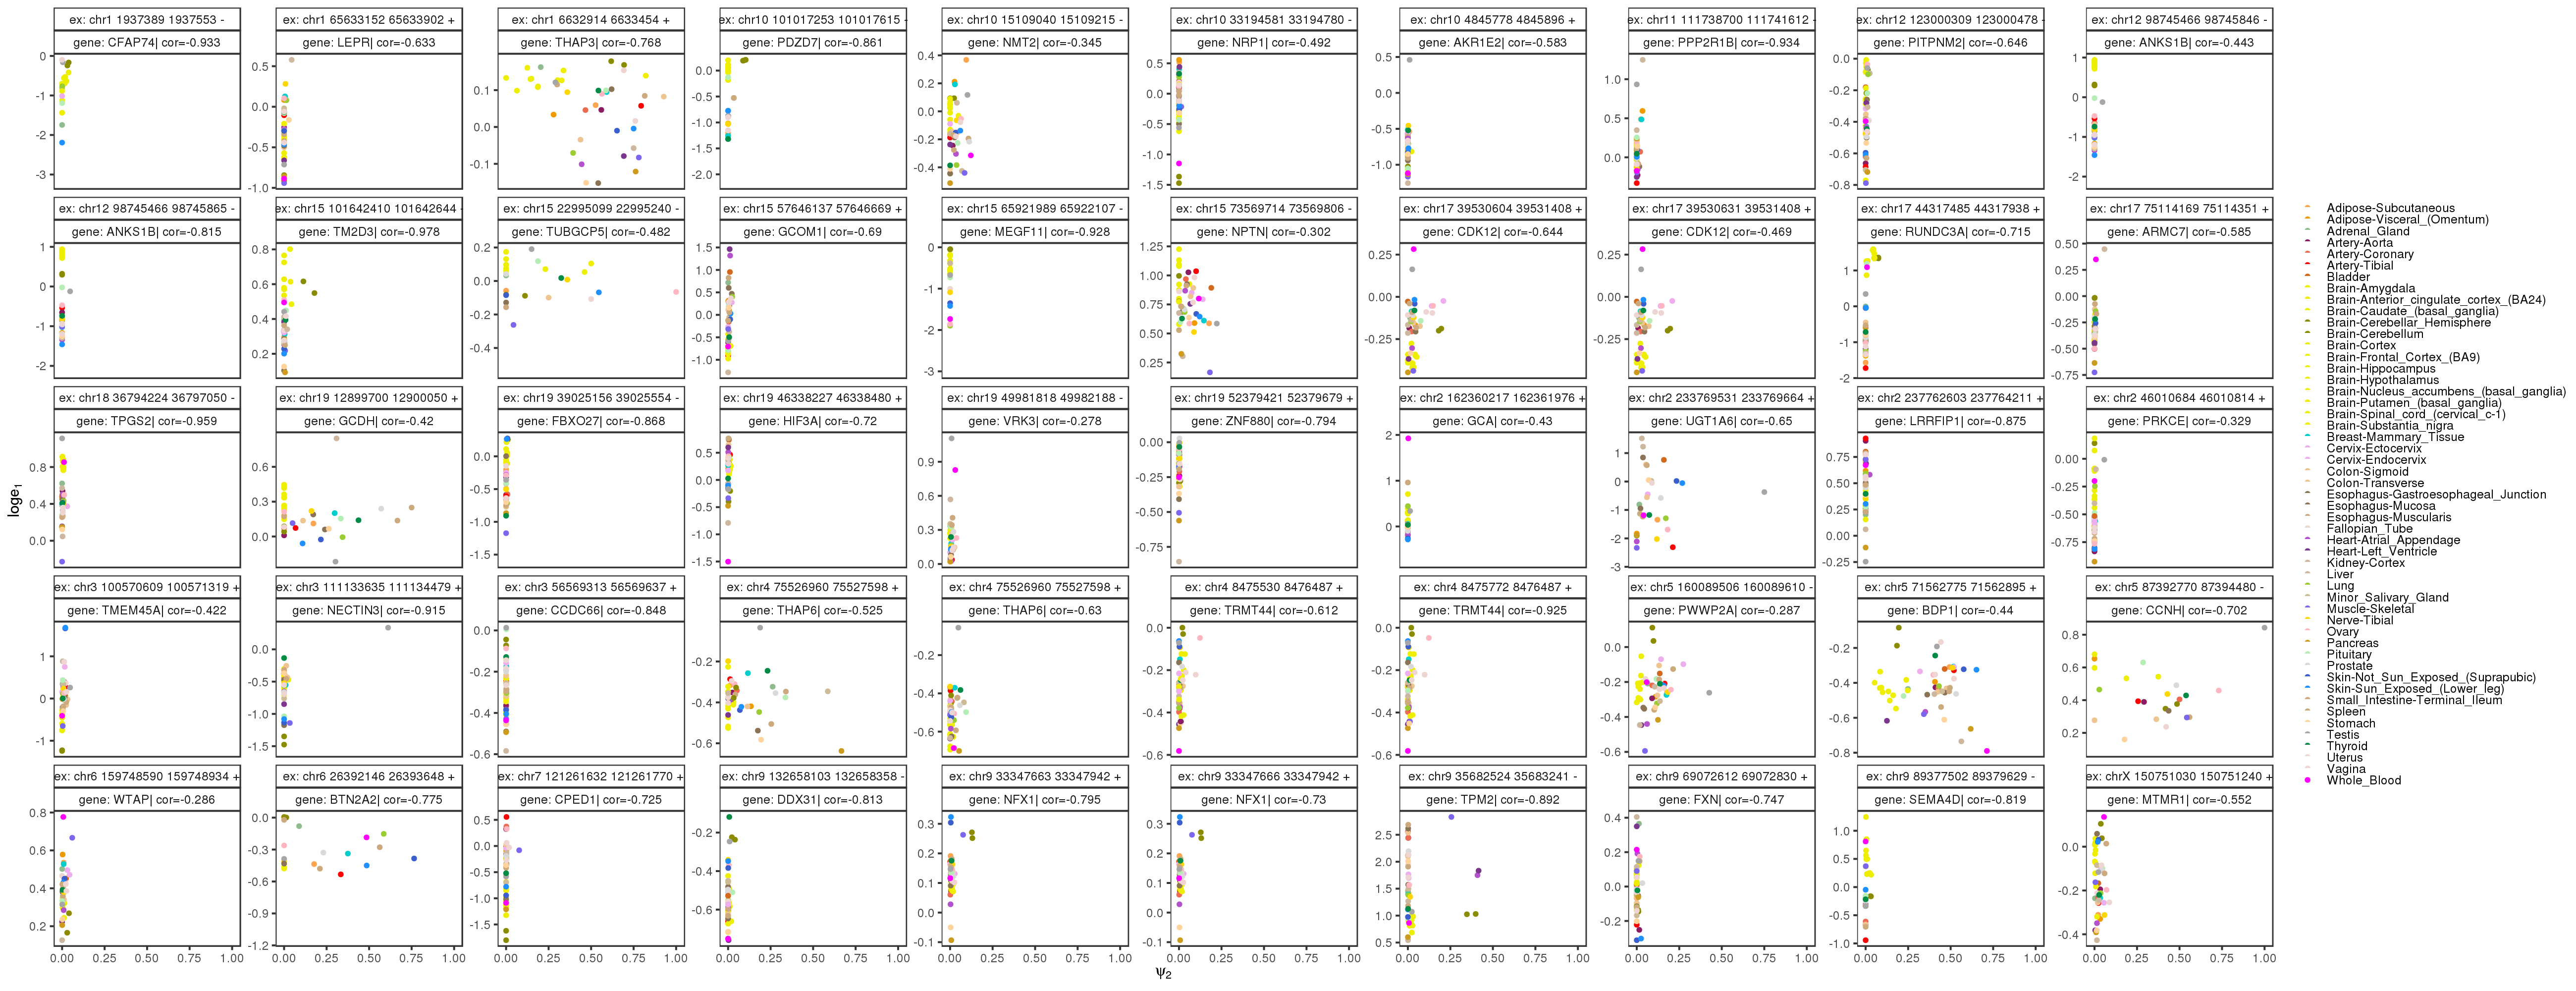

In [102]:
options(repr.plot.width = 26, repr.plot.height = 10, repr.plot.res = 200)

ggplot(cov_junc_exp_tis_plot,
    aes(x = psi2, y = log10(e1), color = tissue)) +
    geom_point(size = 1) + #aes(size=log10(loc_exp))) +
    facet_wrap(. ~ ex + `gene`, scales = "free_y", nrow = 5, labeller = label_both) +
    #scale_y_continuous(trans= "log2",breaks = c(0,0.005,0.01,0.025,0.05,0.1,0.15,0.25,0.45,0.6,0.75,0.9,1,1.25,2))+
    scale_color_manual(values = gtex_smtsd) +
    ylab(TeX("$log \\e_1$")) + 
    xlab(TeX("$\\psi_2$")) +
    theme_blank +
    theme(
        legend.position = "right", legend.title = element_blank(),
        legend.spacing.y = unit(-9, "pt")) +
    guides(colour = guide_legend(ncol = 1, byrow = TRUE))
ggsave(filename = "panel_psi2_e1.allcases.dtau025_qval01.n50_noUGTduplicates.pdf",
    device = "pdf", path = pictures_dir, width=26, height=10)

Warning message:
"Removed 414 rows containing missing values (`geom_point()`)."


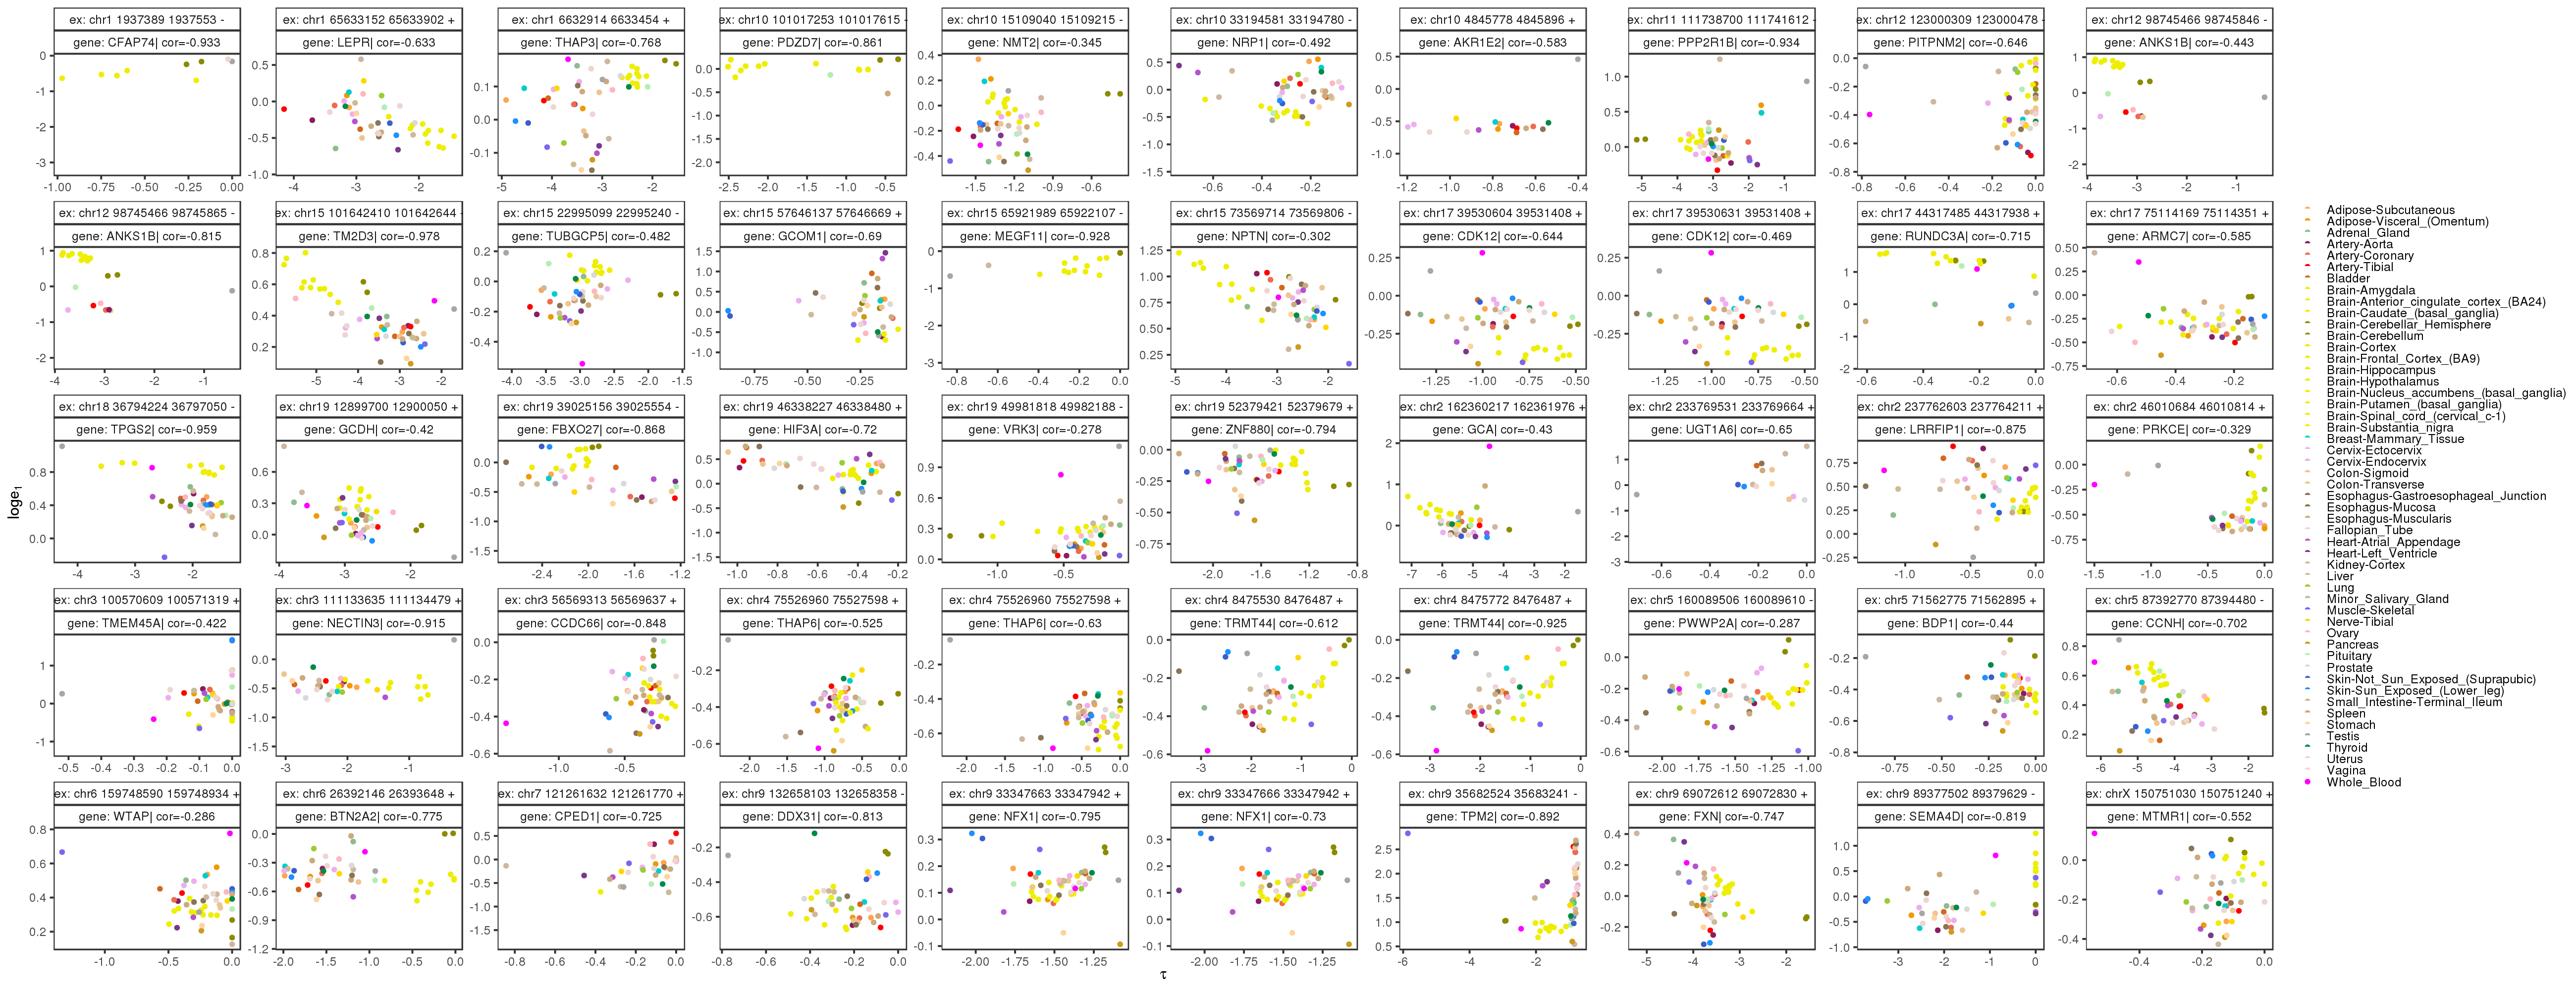

In [197]:
options(repr.plot.width = 26, repr.plot.height = 10, repr.plot.res = 200)

ggplot(cov_junc_exp_tis_plot,
    aes(x = log2(e2_e1), y = log10(e1), color = tissue)) +
    geom_point(size = 1) + #aes(size=log10(loc_exp))) +
    facet_wrap(. ~ ex + `gene`, scales = "free", nrow = 5, labeller = label_both) +
    #scale_y_continuous(trans= "log2",breaks = c(0,0.005,0.01,0.025,0.05,0.1,0.15,0.25,0.45,0.6,0.75,0.9,1,1.25,2))+
    scale_color_manual(values = gtex_smtsd) +
    ylab(TeX("$log \\e_1$")) + 
    xlab(TeX("$\\tau$")) +
    theme_blank +
    theme(
        legend.position = "right", legend.title = element_blank(),
        legend.spacing.y = unit(-9, "pt")) +
    guides(colour = guide_legend(ncol = 1, byrow = TRUE))
#ggsave(filename = "panel_psi2_e1.allcases.dtau025_qval01.n50_noUGTduplicates.pdf",
 #   device = "pdf", path = pictures_dir, width=26, height=10)

### Other Supp Figures

**SF plot: e1e2 ecdf based on joint set**

Warning message:
“Removed 308 rows containing non-finite values (`stat_ecdf()`).”


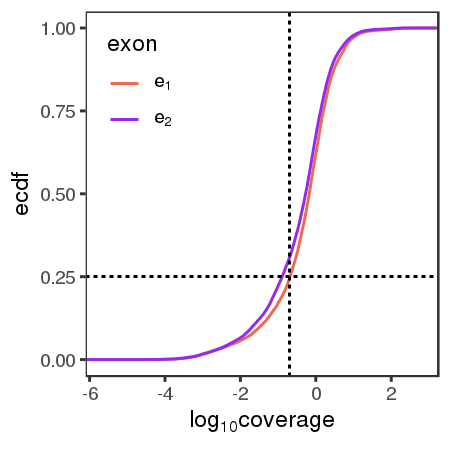

In [102]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 150)

cov_junc_tis_join %>% pivot_longer(c(e2,e1),names_to="exon",values_to = "coverage") %>% 
#mutate(exon=factor(exon,labels=c(TeX("$e_1$"),TeX("$e_2$")))) %>% 
ggplot(aes(x=log10(coverage),color=exon))+stat_ecdf()+
#+geom_histogram(bins=50)+
#facet_grid(exon~.)+
geom_vline(xintercept = log10(0.2),lty=2)+
geom_hline(yintercept = 0.25,lty=2)+
#scale_x_continuous(trans="log10")+
scale_color_manual(values = c("coral2","purple2"),
                   labels=unname(c(TeX("$e_1$"),TeX("$e_2$"))))+
theme_blank+theme(legend.position = c(0.15,0.8))+xlab(TeX("$log_{10}coverage$"))
ggsave(filename = "e1_e2_ecdf_PEATE_nJ.pdf",
       device = "pdf", path = pictures_dir, width=3,height=3)
#deleted the 25% of events with the lowest e1 coverage

### threshold effect SF

by dpsi1 | fixed dtau

In [41]:
bydpsi_df <- map_dfr(
    c(0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.75, 0.85),
    function(psi1_thr) {
        tibble(
            de2e1_t = DE2E1_TIS,
            psi1_t = psi1_thr,
            `by psi1` = with(cov_junc_exp_tis_cor, sum(range_psi1 >= psi1_thr, na.rm = T)),
            #e2_e1_n=52;#with(cov_junc_exp_tis_filt_cor,sum(min_e2_e1<=e2e1_thr))
            intersection0 =
                with(cov_junc_exp_tis_cor,
                    sum(range_psi1 >= psi1_thr & de2e1 >= DE2E1_TIS, na.rm = T)),
            intersection =
                with(cov_junc_exp_tis_cor,
                    sum(range_psi1 >= psi1_thr & de2e1 >= DE2E1_TIS & cor_psi_e2e1_qval < COR_Q, na.rm = T)),
        )
    })  %>% 
 
mutate(N = dim(cov_junc_exp_tis_cor)[1], 
       by_tau = with(cov_junc_exp_tis_cor, sum(de2e1 >= DE2E1_TIS, na.rm = T)),
       by_tau_cor = with(cov_junc_exp_tis_cor, sum(de2e1 >= DE2E1_TIS & cor_psi_e2e1_qval < COR_Q, na.rm = T)),
       perc = intersection/`by psi1`,
       perc_cor = intersection/intersection0,
       tau_pval= phyper(q = intersection0, m = by_tau, n = N - by_tau, k = `by psi1`, lower.tail = F),
       cor_pval= phyper(q = intersection, m = by_tau_cor, n = N - by_tau_cor, k = `by psi1`, lower.tail = F)) 

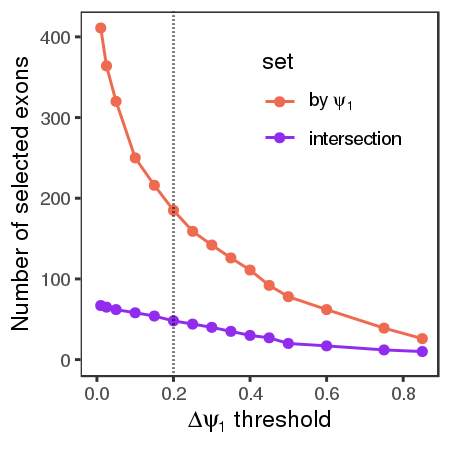

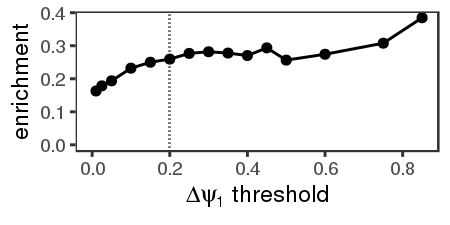

In [42]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 150)

bydpsi_df %>% 
    pivot_longer(cols = c(`by psi1`, intersection), names_to = "set", values_to = "hits") %>% 
    ggplot(.,aes(x = psi1_t, y = hits, color = set)) +
    geom_point() + geom_line() +
    geom_vline(xintercept = round(RANGE_PSI1, dig = 1), lty = 3) +
    scale_color_manual(
        values = c("coral2", "purple2"),
        labels = unname(c(TeX("by $\\psi_1$"), "intersection"))) +
    ylab("Number of selected exons") +
    xlab(TeX("$\\Delta\\psi_1$ threshold")) +
    coord_cartesian(ylim = c(0, NA), xlim = c(0, NA)) +
    theme_blank +
    theme(legend.position = c(0.7, 0.75), legend.text.align = 0)
ggsave(filename = "SF_for2C_1.all.pdf",device = "pdf", path = pictures_dir, width = 3.5, height = 3)

options(repr.plot.width = 3, repr.plot.height = 1.5, repr.plot.res = 150)

bydpsi_df %>% 
pivot_longer(cols = c(perc), names_to = "set", values_to = "enrichment") %>% 
    ggplot(.,aes(x = psi1_t, y = enrichment)) +
    geom_point() + geom_line() +
    geom_vline(xintercept = round(RANGE_PSI1, digits = 1), lty = 3) +
    xlab(TeX("$\\Delta\\psi_1$ threshold")) +
    coord_cartesian(ylim = c(0, NA), xlim = c(0, NA)) +
    theme_blank 
#ggsave(filename = "SF_for2C_1.enrich.all.pdf",device = "pdf", path = pictures_dir, width = 3.5, height = 1.5)

by dtau | fixed dpsi1

In [207]:
bydtau_df <- map_dfr(
    c(0.01, seq(0.026, 0.8, by = 0.05)),
    function(de2e1_thr) {
        tibble(
            de2e1_t = de2e1_thr,
            psi1_t = RANGE_PSI1,
            `by tau` = with(cov_junc_exp_tis_cor, sum(de2e1 >= de2e1_thr)),
            intersection0 =
                with(cov_junc_exp_tis_cor,
                    sum(range_psi1 >= RANGE_PSI1 & de2e1 >= de2e1_thr, na.rm = T)),
            intersection = with(
                cov_junc_exp_tis_cor,
                sum(range_psi1 >= RANGE_PSI1 & de2e1 >= de2e1_thr & cor_psi_e2e1_qval < COR_Q, na.rm = T)),
        )}) %>% 

    mutate(N = dim(cov_junc_exp_tis_cor)[1], 
       by_psi = with(cov_junc_exp_tis_cor, sum(range_psi1 >= RANGE_PSI1, na.rm = T)),
       by_psi_cor = with(cov_junc_exp_tis_cor,
                         sum(range_psi1 >= RANGE_PSI1 & cor_psi_e2e1_qval < COR_Q, na.rm = T)),
       perc = intersection/`by tau`,
       perc_cor = intersection/intersection0,
       tau_pval= phyper(q = intersection0, m = by_psi, n = N - by_psi, k = `by tau`, lower.tail = F),
       cor_pval= phyper(q = intersection, m = by_psi_cor, n = N - by_psi_cor, k = `by tau`, lower.tail = F))

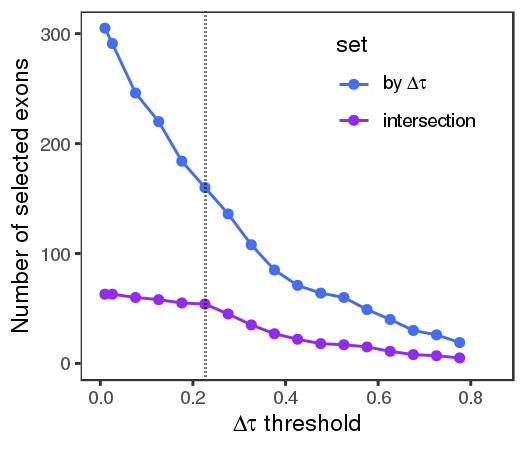

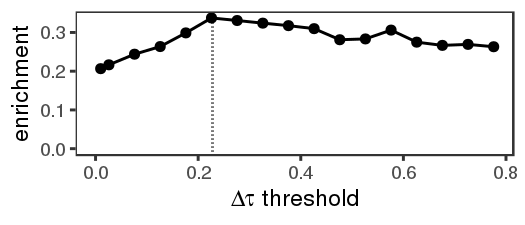

In [213]:
options(repr.plot.width = 3.5, repr.plot.height = 3, repr.plot.res = 150)

bydtau_df %>% 
    pivot_longer(cols = c(`by tau`, intersection), names_to = "set", values_to = "N hits") %>%
    ggplot(.,
        aes(x = de2e1_t, y = `N hits`, color = set)) +
    geom_point() + geom_line() +
    geom_vline(xintercept = DE2E1_TIS-0.02, lty = 3)+
    scale_color_manual(
        values = c("royalblue2", "purple2"),
        labels = unname(c(TeX("by $\\Delta\\tau$"), "intersection"))) +
    theme_blank +
    theme(
        legend.position = c(0.75, 0.8),
        legend.background = element_rect(fill = "transparent"),
        legend.text.align = 0) +
    coord_cartesian(ylim = c(0, NA), xlim = c(0, 0.85)) +
    ylab("Number of selected exons") + 
    xlab(TeX("$\\Delta\\tau$ threshold"))

ggsave(filename = "SF_for2C_2.all.pdf",device = "pdf", path = pictures_dir, width = 3.5, height = 3)

options(repr.plot.width = 3.5, repr.plot.height = 1.5, repr.plot.res = 150)
bydtau_df %>% 
pivot_longer(cols = c(perc), names_to = "set", values_to = "enrichment") %>% 

    ggplot(.,aes(x = de2e1_t, y = enrichment)) +
    geom_point() + geom_line() +
    geom_vline(xintercept = DE2E1_TIS-0.02, lty = 3) +
    xlab(TeX("$\\Delta\\tau$ threshold")) +
    coord_cartesian(ylim = c(0, NA), xlim = c(0, NA)) +
    theme_blank 

ggsave(filename = "SF_for2C_2.enrich.all.pdf", device = "pdf", path = pictures_dir, width = 3.5, height = 1.5)

### venn diagram

In [48]:
library(VennDiagram)

Loading required package: grid

Loading required package: futile.logger



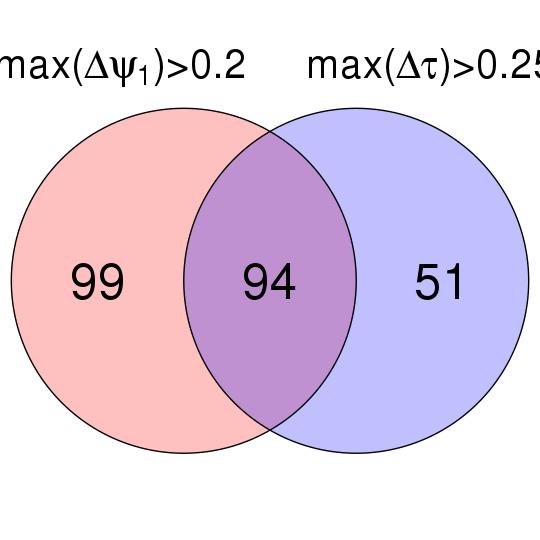

In [79]:
options(repr.plot.width = 2.7, repr.plot.height = 2.7, repr.plot.res = 200)

cov_junc_sum <- cov_junc_exp_tis_cor %>%
    mutate(id = paste(ex,E_junc, sep = "|"))

gtex_venn <- with(cov_junc_sum,
    draw.pairwise.venn(
        area1 = n_distinct(id[de2e1 >= DE2E1_TIS], na.rm = T),
        area2 = n_distinct(id[range_psi1 >= RANGE_PSI1], na.rm = T),
        cross.area = n_distinct(id[de2e1 >= DE2E1_TIS & range_psi1 >= RANGE_PSI1], na.rm = T),
        category = c(
            TeX("$max(\\Delta\\tau) > 0.25$"),
            TeX("$max(\\Delta\\psi_1) > 0.2$")),
        reverse = TRUE, #fill=c("NA","blue","white"),
        lwd = 0.5, cex = c(1.5, 1.5, 1.5), fontfamily = "Liberation Sans",
        cat.cex = 1.2, cat.pos = c(0, 0),
        cat.fontfamily = rep("Liberation Sans", 2),
        cat.just = list(c(0.2, 0), c(0.75, 0)),
        fill = c("blue", "red"), alpha = rep(0.25, 2),
        scaled = FALSE)
)

In [81]:
cov_junc_sum %>%
    filter(
        range_psi1 >= RANGE_PSI1,
        de2e1 >= DE2E1_TIS
    ) %>%
    with(., n_distinct(id))

cov_junc_sum %>%
    filter(
        range_psi1 >= RANGE_PSI1,
        de2e1 >= DE2E1_TIS,
        cor_psi_e2e1_qval < COR_Q
    )  %>% arrange(ex) %>%
    with(., n_distinct(id))
#with(.,n_distinct(ex, E_junc, gene_name))#UGT genes add two

[1] 94

[1] 50

In [76]:
gtex_filt_ST %>%
    select(-c(stop_cod, reads, case)) %>% 
    arrange(gene_name) %>% 
    unique

,gene_name,ex,E_junc,n,min_e2e1,max_e2e1,range_psi1,cor_psi_e2e1,cor_psi_e2e1_pval,cor_psi_e2e1_qval,de2e1
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AKR1E2,chr10_4845778_4845896_+,chr10_4842504_4847148_+,17,0.436188606,0.7569613,0.2582781,-0.5833333,7.869478e-03,2.988410e-02,0.3207727
2,ANKS1B,chr12_98745466_98745846_-,98735634_98751355,21,0.069092962,0.7386448,0.9643548,-0.4428571,2.287765e-02,7.075561e-02,0.6695518
3,ANKS1B,chr12_98745466_98745865_-,98735634_98751355,20,0.069092962,0.7386448,0.2000000,-0.8145920,6.138012e-06,4.200290e-05,0.6695518
4,ARMC7,chr17_75114169_75114351_+,75110606_75128677,50,0.625328108,0.9358823,0.3845881,-0.5846339,6.160426e-06,4.200290e-05,0.3105542
5,BDP1,chr5_71562775_71562895_+,chr5_71562520_71564754_+,49,0.533778713,1.0000000,0.7317815,-0.4396541,7.867025e-04,3.806625e-03,0.4662213
6,BTN2A2,chr6_26392146_26393648_+,26390829_26394298,25,0.251466213,0.9894903,1.0000000,-0.7747644,2.726884e-06,1.995281e-05,0.7380240
7,CCDC66,chr3_56569313_56569637_+,56567053_56571181,51,0.378994150,0.9267062,0.6675003,-0.8476923,0.000000e+00,0.000000e+00,0.5477121
8,CCNH,chr5_87392770_87394480_-,87312795_87395044,46,0.013877231,0.3386023,0.9262295,-0.7024091,2.654227e-08,2.654227e-07,0.3247250
9,CDK12,chr17_39530604_39531408_+,39526316_39544249,51,0.378350792,0.7125478,0.3925960,-0.6441629,3.588915e-07,3.076213e-06,0.3341970


# NMD inhibition data
NMD inhibition Venn diagrams code from CHX_published_ATE_PE_chess_allPAS.novel_junc_PAS.ipynb

In [82]:
E2E1ctrl = 0.7
IRATIOctrl = 0.75
DIRATIO = -0.022
DPSI = 0.014

### NMD inhibition data for novel junc ATEPE (case III)

In [83]:
load(file = "CHX_data/ate_ex_join.novel_junc.n260.RData")#ate_ex_join
ate_ex_join_nJ  <- ate_ex_join %>%
    mutate(CHX = factor(CHX, levels = c("ctrl", "CHX", "RIPiT"), labels = c("ctrl", "CHX", "CHX")))

In [84]:
ate_ex_join_d_nJ <- ate_ex_join_nJ %>%
    filter(
        !grepl(pat = "unpub", x = cell_line) &
        !grepl(pat = "PC3", x = cell_line)) %>% 
    dplyr::select(-c(e1, e2)) %>% 
    mutate(psinmd = ifelse(reads_I1 + reads_E >= 10, reads_I2 / (reads_I1 + reads_E), NA)) %>%

    #low expression via NMD can make psi1, psi2 and e2_e1 NA => for max d_ in ctrl: psi1=0, e2_e1=1, psi=0
    mutate(
        across(c(psi1, psi2, psinmd), ~ifelse(CHX == "ctrl" & is.na(.x), 0, .x)),
        e2_e1 = ifelse(CHX == "ctrl" & is.na(e2_e1), 1, e2_e1),
        Iratio = ifelse(CHX == "ctrl" & is.na(Iratio), 0.5, Iratio)) %>% 
    group_by(ex, stop_cod, gene_name, E_junc, tr_id, cell_line) %>% 
    mutate(
        across(
            c(psi1, psi2, psinmd, Iratio, e2_e1, cov_e1),
            ~.x[CHX == "CHX"] - .x[CHX == "ctrl"],
            .names = "d_{.col}"))

(ate_ex_join_f_nJ  <- ate_ex_join_d_nJ %>% 
    filter(
        any((e2_e1 < E2E1ctrl | Iratio > IRATIOctrl) & CHX == "ctrl"),#pA in ctrl
        d_Iratio < DIRATIO, #less pA among PA&PE in NMD
        d_psi2 > DPSI) %>% 
    ungroup %>% arrange(gene_name)
)
n_distinct(ate_ex_join_f_nJ$ex)

ex,stop_cod,gene_name,tr_id,E_junc,cell_line,CHX,reads_I1,reads_I2,reads_E,⋯,psi1,psi2,e2_e1,psinmd,d_psi1,d_psi2,d_psinmd,d_Iratio,d_e2_e1,d_cov_e1
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr17_39530604_39531408_+,39531316,CDK12,"CHS.22063.3,CHS.22063.34",39526316_39544249,iPS cell-derived bronchioalveolar organoids,CHX,45,5,11,⋯,0.80357143,0.31250000,0.14164609,0.08928571,0.218205575,0.31250000,0.08928571,-0.10000000,-0.091909231,20.311258
chr17_39530604_39531408_+,39531316,CDK12,"CHS.22063.3,CHS.22063.34",39526316_39544249,iPS cell-derived bronchioalveolar organoids,ctrl,24,0,17,⋯,0.58536585,0.00000000,0.23355532,0.00000000,0.218205575,0.31250000,0.08928571,-0.10000000,-0.091909231,20.311258
chr17_39530631_39531408_+,39531316,CDK12,"CHS.22063.31,CHS.22063.35",39526316_39544249,iPS cell-derived bronchioalveolar organoids,CHX,48,5,11,⋯,0.81355932,0.31250000,0.14164609,0.08474576,0.199922958,0.31250000,0.08474576,-0.09433962,-0.091909231,20.311258
chr17_39530631_39531408_+,39531316,CDK12,"CHS.22063.31,CHS.22063.35",39526316_39544249,iPS cell-derived bronchioalveolar organoids,ctrl,27,0,17,⋯,0.61363636,0.00000000,0.23355532,0.00000000,0.199922958,0.31250000,0.08474576,-0.09433962,-0.091909231,20.311258
chr10_100199001_100199168_-,100199101,CHUK,CHS.6975.10,100194521_100199971,HeLa,CHX,4,6,127,⋯,0.03053435,0.04511278,0.67719128,0.04580153,0.030534351,0.04511278,0.04580153,-0.10000000,0.108357213,22.870000
chr10_100199001_100199168_-,100199101,CHUK,CHS.6975.10,100194521_100199971,HeLa,ctrl,0,0,37,⋯,0.00000000,0.00000000,0.56883407,0.00000000,0.030534351,0.04511278,0.04580153,-0.10000000,0.108357213,22.870000
chr3_3172506_3172646_-,3172589,CRBN,CHS.36464.16,3167793_3172776,A549,ctrl,54,6,61,⋯,0.46956522,0.08955224,0.66019631,0.05217391,-0.009388226,0.30648737,0.30180839,-0.33478261,0.125012257,8.533333
chr3_3172506_3172646_-,3172589,CRBN,CHS.36464.16,3167793_3172776,A549,CHX,52,40,61,⋯,0.46017699,0.39603960,0.78520857,0.35398230,-0.009388226,0.30648737,0.30180839,-0.33478261,0.125012257,8.533333
chr3_3172506_3172646_-,3172589,CRBN,CHS.36464.16,3167793_3172776,HeLa,CHX,74,47,72,⋯,0.50684932,0.39495798,0.77045330,0.32191781,0.106849315,0.22254419,0.19691781,-0.15033451,0.006536312,23.843333


[1] 19

### NMD inhibition data for ATEPE from PAS (case I, II)

In [ ]:
ate_ex <- read.table(paste0(pas_dat, "ATE_PE_chess_allpas_n675.tab"), header = T, stringsAsFactors = F) %>% 
    select(-c("db_xref.ate", "db_xref.nmd", "max_TPM.nmd", "max_TPM.ate")) %>%
    mutate(
        source = factor(
            x = source, ordered = T,
            levels = c("pAread", "atlas", "atlas,pAread", "TE", "pAread,TE", "atlas,TE", "atlas,pAread,TE"))) %>% 

    #PAS with high support 
    filter(grepl(source, pat = "TE") | (pAread > 10 | atlas_exp >= 0.25)) %>%

    #summarize into one TE for each nmd_transcript:
    group_by(ex, transcript_id, E, stop_cod, gr_50bp, I1, I2, gene_name, sample_count.nmd) %>% 
    arrange(
        desc(source), desc(sample_count.ate), desc(atlas_exp), desc(pAread), .by_group = T) %>% 
    summarize(
        source = paste(sort(unique(unlist(str_split(string = source, pattern = ",")))), collapse = ","),
        TE = TE[1],
        transcript_id_te = transcript_id_te[1],
        pAread = sum(pAread, na.rm = T),
        atlas_exp = sum(atlas_exp, na.rm = T),
        sample_count.ate = sum(sample_count.ate, na.rm = T),
        #TE=paste(TE,collapse = ","),transcript_id_te=paste(unique(transcript_id_te),collapse = ","),
        .groups = "drop")  %>% 

    #leave one tr_id for each ex,E,I1,I2 set:
    group_by(
        ex, stop_cod, gr_50bp, gene_name, E, I1 ,I2, source, TE, transcript_id_te, sample_count.ate, pAread, atlas_exp) %>% 
    arrange(desc(sample_count.nmd), .by_group = T) %>% 
    summarize(
        transcript_id = transcript_id[1],
        sample_count.nmd = sample_count.nmd[1],
        .groups = "drop") %>% 

    #exchange I1 and I2 for - strand:
    pivot_longer(c(I1, I2, E), names_to = "junc_type", values_to = "junc") %>% 
    mutate(junc_type = ifelse(
        grepl(x = ex, pat = fixed("-")) & !junc_type == "E",
        ifelse(junc_type == "I1", "I2", "I1"),
        junc_type))


ate_ex_filtPAS <- read.table(paste0(pas_dat, "ATE_PE_chess_allpas_n675.tab"), header = T, stringsAsFactors = F) %>% 
    select(-c("db_xref.ate","db_xref.nmd","max_TPM.nmd","max_TPM.ate")) %>%
    mutate(source = factor(x = source, ordered = T ,
                levels = c("pAread","atlas","atlas,pAread","TE","pAread,TE","atlas,TE","atlas,pAread,TE"))) %>% 
    #PAS with high support
    filter(grepl(source, pat = "TE") | (pAread >= 49 | atlas_exp >= 0.5)) %>% 
    #summarize into one TE for each nmd_transcript:
    group_by(ex, transcript_id, E, stop_cod, gr_50bp, I1, I2, gene_name, sample_count.nmd) %>% 
    arrange(desc(source),desc(sample_count.ate),desc(atlas_exp),desc(pAread),.by_group = T) %>% 
    summarize(
        source = paste(sort(unique(unlist(str_split(string = source, pattern = ",")))), collapse=","),
        TE = TE[1],
        transcript_id_te = transcript_id_te[1],
        pAread = sum(pAread, na.rm = T),
        atlas_exp = sum(atlas_exp, na.rm = T),
        sample_count.ate = sum(sample_count.ate, na.rm = T),
        .groups = "drop") %>% 
    #leave one tr_id for each ex,E,I1,I2 set:
    group_by(ex, stop_cod, gr_50bp, gene_name, E, I1, I2, source, TE, transcript_id_te, sample_count.ate, pAread,atlas_exp) %>% 
    arrange(desc(sample_count.nmd), .by_group = T) %>% 
    summarize(
        transcript_id = transcript_id[1],
        sample_count.nmd = sample_count.nmd[1],
        .groups = "drop") %>% 
    #exchange I1 and I2 for - strand:
    pivot_longer(c(I1, I2, E), names_to = "junc_type", values_to = "junc") %>% 
    mutate(junc_type = ifelse(
        grepl(x = ex, pat = fixed("-")) & !junc_type == "E",
        ifelse(junc_type == "I1", "I2", "I1"), junc_type))

In [88]:
load("CHX_data/sur_ex_all.PAS10_025.surround_exon_coverage.published_CHX.ATE_PE_chess_allpas_n675.RData")
load("CHX_data/ate_ex_counts.PAS10_025.junc_counts.published_CHX.ATE_PE_chess_allpas_n675.RData")

In [89]:
ate_ex_counts <- ate_ex_counts %>%  #extract CHX
    filter(!is.na(cell_line)) %>% 
    unique %>% 
    #filter(gr_50bp) %>% 
    select(-junc) %>% 
    pivot_wider(
        names_from = junc_type,
        names_prefix = "reads_",
        values_from = "split_reads", values_fill = 0)

sur_ex_all <- ate_ex %>% 
    #select(ex,stop_cod,TE,transcript_id,junc_type,junc) %>% 
    filter(junc_type == "E") %>% 
    select(-junc_type) %>% 
    mutate(
        E_junc = gsub(junc,
            pat = "chr[[:digit:]XYM]+_|_[-+]", rep = ""),
        .keep = "unused") %>%
    left_join(sur_ex_all, .)

Joining with `by = join_by(ex, E_junc)`
Warning message in left_join(sur_ex_all, .):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 929 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.”


In [90]:
treatments_df <- select(ate_ex_counts, c(cell_line, CHX)) %>% 
    unique %>% 
    arrange(cell_line, CHX)

ate_ex_uniq <- ate_ex %>% 
    filter(junc_type == "E") %>% 
    select(-junc_type) %>% 
    mutate( E_junc = gsub(junc, pat = "chr[[:digit:]XYM]+_|_[-+]", rep = ""), .keep = "unused")  %>% 
    unique

ate_ex_counts_full <- cross_join(ate_ex_uniq, treatments_df) %>% 
    left_join(
        select(ate_ex_counts,
            -c(gr_50bp, source, transcript_id_te, sample_count.ate, pAread, atlas_exp, sample_count.nmd)))  %>% 
    mutate(across(starts_with("reads_"), ~ replace_na(.x, replace = 0))) %>% 
    arrange(ex, stop_cod, gene_name)
dim(ate_ex_counts_full)

ate_ex_join <- left_join(ate_ex_counts_full, sur_ex_all) %>% 
    filter(gr_50bp)
dim(ate_ex_join)
ate_ex_join %>% filter(reads_I1 + reads_I2 + reads_E == 0) %>% dim

Joining with `by = join_by(ex, stop_cod, gene_name, TE, transcript_id, cell_line, CHX)`


[1] 9576   18

Joining with `by = join_by(ex, stop_cod, gr_50bp, gene_name, source, TE, transcript_id_te, sample_count.ate, pAread, atlas_exp, transcript_id, sample_count.nmd, E_junc, cell_line, CHX)`


[1] 5274   22

[1] 837  22

In [91]:
ate_ex_join <- ate_ex_join %>% 
    mutate(
        #CHX = replace_na("-CHX"), 
        CHX = factor(CHX, levels = c(TRUE, FALSE), labels = c("CHX", "ctrl")),
        Iratio = ifelse((reads_I1 + reads_I2) >= 10, reads_I1 / (reads_I1 + reads_I2), NA),
        psi = ifelse(
            (2 * reads_E + reads_I1 + reads_I2) >= 10,
            (reads_I1 + reads_I2) / (2 * reads_E + reads_I1 + reads_I2), NA),
        psi1 = ifelse(reads_E + reads_I1 >= 10, reads_I1 / (reads_E + reads_I1), NA),
        psi2 = ifelse(reads_E + reads_I2 >= 10, reads_I2 / (reads_E + reads_I2), NA),
        psinmd = ifelse(reads_E + reads_I1 >= 10, reads_I2 / (reads_E + reads_I1), NA),
        e2_e1 = ifelse(cov_e1 > 0.2, cov_e2 / cov_e1, NA))

dCHX

In [92]:
ate_ex_join_d_pe <- ate_ex_join %>%
    filter(ex %in% ate_ex_filtPAS$ex) %>% 
    filter(
        !grepl(pat = "unpub", x = cell_line),
        !grepl(pat = "PC3", x = cell_line)) %>% 
    #left_join(.,dplyr::select(ATE_PE_Ej_PAStype,-c(E,source))) %>% 
    dplyr::select(-c(sample_count.ate, pAread, 
        atlas_exp, sample_count.nmd, source, gr_50bp, e1, e2)) %>% 

    #low expression via NMD can make psi1, psi2 and e2_e1 NA => for max d_ in ctrl: psi1=0, e2_e1=1, psi=0
    mutate(
        across(
            c(psi1, psi2, psi, psinmd),
            ~ifelse(CHX == "ctrl" & is.na(.x), 0, .x)),
        e2_e1 = ifelse(CHX == "ctrl" & is.na(e2_e1), 1, e2_e1),
        Iratio = ifelse(CHX == "ctrl" & is.na(Iratio), 0.5, Iratio)) %>%

    group_by(ex, stop_cod, gene_name, TE, transcript_id, E_junc, cell_line) %>%

    mutate(
        across(
            c(psi1, psi2, psinmd, Iratio, e2_e1, cov_e1),
            ~.x[CHX == "CHX"] - .x[CHX == "ctrl"], 
            .names = "d_{.col}")) %>% 
    ungroup(transcript_id) %>% select(-transcript_id) %>% unique

(ate_ex_join_f_pe <- ate_ex_join_d_pe %>% 
    filter( 
        any((e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl") & #pA in ctrl
        (d_Iratio <= DIRATIO) & #less pA among PA&PE in NMD
        (d_psi2 >= DPSI)) %>% ungroup %>% 
    arrange(gene_name)
)
n_distinct(ate_ex_join_f_pe$ex)

ex,stop_cod,gene_name,TE,transcript_id_te,E_junc,cell_line,CHX,reads_I2,reads_E,reads_I1,cov_e1,cov_e2,Iratio,psi,psi1,psi2,psinmd,e2_e1,d_psi1,d_psi2,d_psinmd,d_Iratio,d_e2_e1,d_cov_e1
<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr15_64950954_64951233_+,64951015,ANKDD1A,64955087,NA,64949972_64957103,A549,ctrl,1,7,10,25.022727,22.6821192,0.9090909,0.44000000,0.58823529,0.00000000,0.05882353,0.90646071,0.04139434,0.50000000,0.31154684,-0.27946128,0.630405090,-10.4924242
chr15_64950954_64951233_+,64951015,ANKDD1A,64955087,NA,64949972_64957103,A549,CHX,10,10,17,14.530303,22.3311258,0.6296296,0.57446809,0.62962963,0.50000000,0.37037037,1.53686580,0.04139434,0.50000000,0.31154684,-0.27946128,0.630405090,-10.4924242
chr1_235176748_235176903_-,235176890,ARID4B,235176417,NA,235175399_235177800,HeLa,ctrl,0,13,0,16.942982,10.0629139,0.5000000,0.00000000,0.00000000,0.00000000,0.00000000,0.59392813,0.46153846,0.51485149,0.57142857,-0.05319149,0.017043245,50.2960526
chr1_235176748_235176903_-,235176890,ARID4B,235176417,NA,235175399_235177800,HeLa,CHX,52,49,42,67.239035,41.0811258,0.4468085,0.48958333,0.46153846,0.51485149,0.57142857,0.61097138,0.46153846,0.51485149,0.57142857,-0.05319149,0.017043245,50.2960526
chr2_175092543_175092616_-,175092614,ATF2,175092435,NA,175080765_175093061,A549,ctrl,4,74,12,126.026490,148.1226415,0.7500000,0.09756098,0.13953488,0.05128205,0.04651163,1.17532942,0.24182105,0.34038462,0.35179346,-0.26086957,-0.189198495,71.1324503
chr2_175092543_175092616_-,175092614,ATF2,175092435,NA,175080765_175093061,A549,CHX,47,73,45,197.158940,194.4245283,0.4891304,0.38655462,0.38135593,0.39166667,0.39830508,0.98613093,0.24182105,0.34038462,0.35179346,-0.26086957,-0.189198495,71.1324503
chr5_71562775_71562895_+,71562786,BDP1,71564359,NA,71562520_71564754,293T,ctrl,2,26,8,13.433775,12.0496689,0.8000000,0.16129032,0.23529412,0.07142857,0.05882353,0.89696820,-0.08529412,0.08906526,0.10367647,-0.32000000,0.007197221,3.2201987
chr5_71562775_71562895_+,71562786,BDP1,71564359,NA,71562520_71564754,293T,CHX,13,68,12,16.653974,15.0579470,0.4800000,0.15527950,0.15000000,0.16049383,0.16250000,0.90416542,-0.08529412,0.08906526,0.10367647,-0.32000000,0.007197221,3.2201987
chr11_119001613_119001825_+,119001676,CENATAC,119010697,NA,118999109_119010764,HeLa,ctrl,0,8,0,11.530303,7.5597015,0.5000000,0.00000000,0.00000000,0.00000000,0.00000000,0.65563771,0.42857143,0.46666667,0.50000000,-0.03846154,0.322807069,19.4242424


[1] 33

### join

In [98]:
df_both <- ungroup(ate_ex_join_d_nJ) %>% 
    select(-tr_id) %>% #mutate(transcript_id = NA) %>% 
    rbind(., select(ungroup(ate_ex_join_d_pe), -c(TE, transcript_id_te))) %>% 
    mutate(id = paste(ex, sep = "|")) %>% 
    unique 

In [99]:
df_both %>% 
    group_by(id, cell_line) %>% 
    filter(
        any((e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
            d_Iratio <= DIRATIO & 
            d_psi2 >= DPSI)) %>% 
    arrange(id)  

ex,stop_cod,gene_name,E_junc,cell_line,CHX,reads_I1,reads_I2,reads_E,cov_e1,cov_e2,Iratio,psi,psi1,psi2,e2_e1,psinmd,d_psi1,d_psi2,d_psinmd,d_Iratio,d_e2_e1,d_cov_e1,id
<chr>,<int>,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr10_100199001_100199168_-,100199101,CHUK,100194521_100199971,HeLa,CHX,4,6,127,68.940000,46.685567,0.4000000,0.03787879,0.03053435,0.04511278,0.67719128,0.04580153,0.03053435,0.04511278,0.04580153,-0.10000000,0.10835721,22.8700000,chr10_100199001_100199168_-
chr10_100199001_100199168_-,100199101,CHUK,100194521_100199971,HeLa,ctrl,0,0,37,46.070000,26.206186,0.5000000,0.00000000,0.00000000,0.00000000,0.56883407,0.00000000,0.03053435,0.04511278,0.04580153,-0.10000000,0.10835721,22.8700000,chr10_100199001_100199168_-
chr10_125792579_125794388_-,125794377,UROS,125789528_125794880,HeLa,CHX,12,9,24,73.202020,5.807947,0.5714286,0.30434783,0.33333333,0.27272727,0.07934135,0.25000000,-0.59523810,0.27272727,0.25000000,-0.42857143,0.06088455,-39.1060606,chr10_125792579_125794388_-
chr10_125792579_125794388_-,125794377,UROS,125789528_125794880,HeLa,ctrl,13,0,1,112.308081,2.072848,1.0000000,0.86666667,0.92857143,0.00000000,0.01845680,0.00000000,-0.59523810,0.27272727,0.25000000,-0.42857143,0.06088455,-39.1060606,chr10_125792579_125794388_-
chr10_125794022_125794388_-,125794377,UROS,125789528_125794880,HeLa,CHX,12,3,24,73.202020,5.807947,0.8000000,0.23809524,0.33333333,0.11111111,0.07934135,0.08333333,-0.59523810,0.11111111,0.08333333,-0.20000000,0.06088455,-39.1060606,chr10_125794022_125794388_-
chr10_125794022_125794388_-,125794377,UROS,125789528_125794880,HeLa,ctrl,13,0,1,112.308081,2.072848,1.0000000,0.86666667,0.92857143,0.00000000,0.01845680,0.00000000,-0.59523810,0.11111111,0.08333333,-0.20000000,0.06088455,-39.1060606,chr10_125794022_125794388_-
chr10_15109040_15109215_-,15109195,NMT2,15106698_15109702,A549,ctrl,21,0,17,52.579710,41.662252,1.0000000,0.38181818,0.55263158,0.00000000,0.79236366,0.00000000,0.17285862,0.06666667,0.01960784,-0.02631579,-0.32318365,6.7318841,chr10_15109040_15109215_-
chr10_15109040_15109215_-,15109195,NMT2,15106698_15109702,A549,CHX,37,1,14,59.311594,27.827815,0.9736842,0.57575758,0.72549020,0.06666667,0.46918001,0.01960784,0.17285862,0.06666667,0.01960784,-0.02631579,-0.32318365,6.7318841,chr10_15109040_15109215_-
chr11_119001613_119001825_+,119001676,CENATAC,118999109_119010764,HeLa,ctrl,0,0,8,11.530303,7.559701,0.5000000,0.00000000,0.00000000,0.00000000,0.65563771,0.00000000,0.42857143,0.46666667,0.50000000,-0.03846154,0.32280707,19.4242424,chr11_119001613_119001825_+


#### Venn Diagram

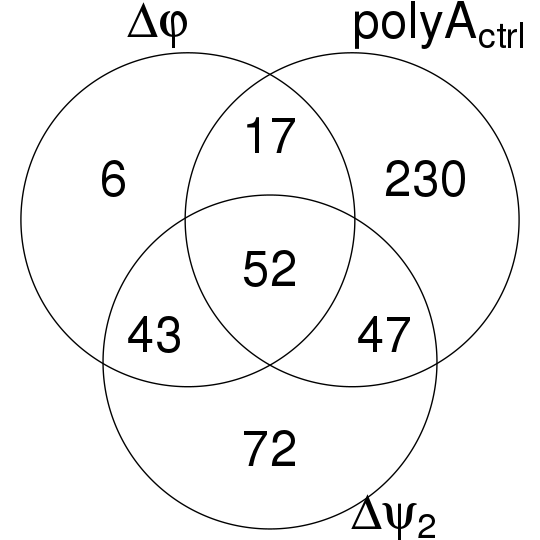

In [100]:
p_width = 2.7; p_height = 2.7
options(repr.plot.width = p_width, repr.plot.height = p_height, repr.plot.res = 200)

vien_both <- with(df_both,
    draw.triple.venn(
        area1 = n_distinct(id[(e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl"], na.rm = T),
        area2 = n_distinct(id[d_Iratio <= DIRATIO], na.rm = T),
        area3 = n_distinct(id[d_psi2 >= DPSI], na.rm = T),
        n12 = n_distinct(
            id[
                (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                d_Iratio <= DIRATIO],
            na.rm = T),
        n23 = n_distinct(
            id[
                d_Iratio <= DIRATIO & 
                d_psi2 >= DPSI], 
            na.rm = T),
        n13 = n_distinct(
            id[
                (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                d_psi2 >= DPSI], 
            na.rm = T),
        n123 = n_distinct(
            id[
                (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                d_Iratio <= DIRATIO & 
                d_psi2 >= DPSI],
            na.rm = T),
        category = c(TeX("$polyA_{ctrl}$"), TeX("$\\Delta\\varphi$"), TeX("$\\Delta\\psi_2$")),
        reverse = TRUE, 
        #fill=c("NA","blue","white"),
        lwd = 0.5, cex = 1.5, #fontfamily ="Arial",
        cat.cex = 1.5, cat.pos = c(0, 0, 150),
        #cat.fontfamily = rep("Liberation Sans", 3),
        cat.just = list(c(1, 0.8), c(0, 0.8), c(0.15, 0.35)))
    )
#grid.draw(venn)+ geom_text(family = "Arial")

CHX and RIPiT separately

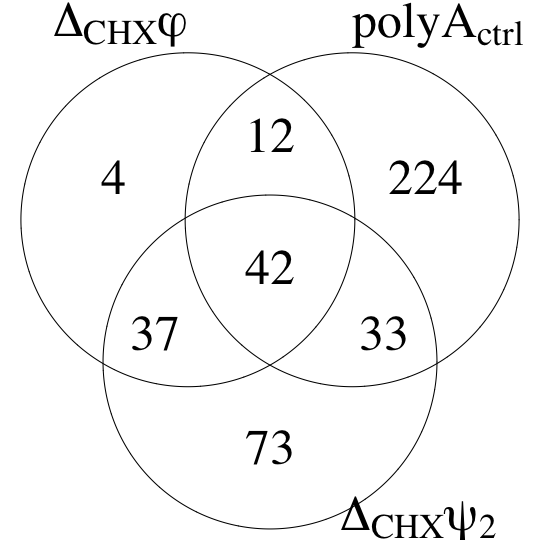

In [284]:
p_width = 2.7; p_height = 2.7
options(repr.plot.width = p_width, repr.plot.height = p_height, repr.plot.res = 200)

vien_chx <- df_both %>% 
    filter(!grepl(pat = "RIP", x = cell_line)) %>% 
    with(.,
        draw.triple.venn(
            area1 = n_distinct(id[(e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl"],na.rm = T),
            area2 = n_distinct(id[d_Iratio <= DIRATIO], na.rm = T),
            area3 = n_distinct(id[d_psi2 >= DPSI], na.rm = T),
            n12 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_Iratio <= DIRATIO],
                na.rm = T),
            n23 = n_distinct(
                id[
                    d_Iratio <= DIRATIO & 
                    d_psi2 >= DPSI], 
                na.rm = T),
            n13 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_psi2 >= DPSI], 
                na.rm = T),
            n123 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_Iratio <= DIRATIO & 
                    d_psi2 >= DPSI],
                na.rm = T),
            category = c(TeX("$polyA_{ctrl}$"), TeX("$\\Delta_{CHX}\\varphi$"), TeX("$\\Delta_{CHX}\\psi_2$")),
            reverse = TRUE, 
            #fill=c("NA","blue","white"),
            lwd = 0.5, cex = 1.5, #fontfamily ="Arial",
            cat.cex = 1.5, cat.pos = c(0, 0, 150),
            #cat.fontfamily = rep("Liberation Sans", 3),
            cat.just = list(c(1, 0.8), c(0, 0.8), c(0.15, 0.35)))
        )

#grid.draw(venn)+ geom_text(family = "Arial")

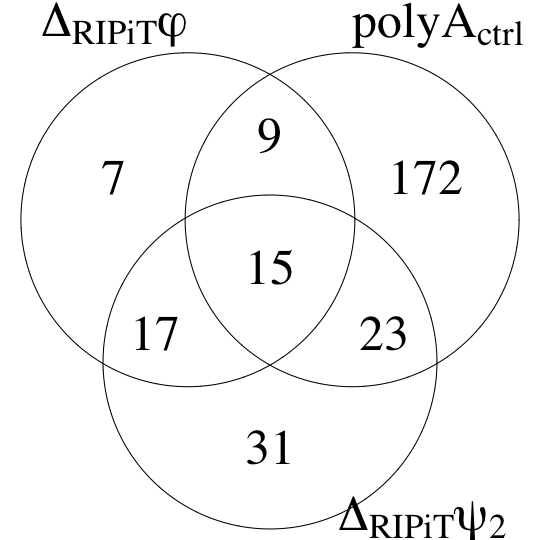

In [285]:
p_width=2.7; p_height = 2.7
options(repr.plot.width = p_width, repr.plot.height = p_height, repr.plot.res = 200)

vien_rip <- df_both %>% 
    filter(grepl(pat = "RIP", x = cell_line)) %>% 
    with(.,
        draw.triple.venn(
            area1 = n_distinct(id[(e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl"],na.rm = T),
            area2 = n_distinct(id[d_Iratio <= DIRATIO], na.rm = T),
            area3 = n_distinct(id[d_psi2 >= DPSI], na.rm = T),
            n12 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_Iratio <= DIRATIO],
                na.rm = T),
            n23 = n_distinct(
                id[
                    d_Iratio <= DIRATIO & 
                    d_psi2 >= DPSI], 
                na.rm = T),
            n13 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_psi2 >= DPSI], 
                na.rm = T),
            n123 = n_distinct(
                id[
                    (e2_e1 <= E2E1ctrl | Iratio >= IRATIOctrl) & CHX == "ctrl" & 
                    d_Iratio <= DIRATIO & 
                    d_psi2 >= DPSI],
                na.rm = T),
            category = c(TeX("$polyA_{ctrl}$"), TeX("$\\Delta_{RIPiT}\\varphi$"), TeX("$\\Delta_{RIPiT}\\psi_2$")),
            reverse = TRUE, 
            #fill=c("NA","blue","white"),
            lwd = 0.5, cex = 1.5, #fontfamily ="Arial",
            cat.cex = 1.5, cat.pos = c(0, 0, 150),
            #cat.fontfamily = rep("Liberation Sans", 3),
            cat.just = list(c(1, 0.8), c(0, 0.8), c(0.15, 0.35)))
        )
#grid.draw(venn)+ geom_text(family = "Arial")

In [286]:
df_both %>% 
    filter(d_psi2 >= DPSI ) %>% 
    select(cell_line, id) %>% 
    mutate(rip = grepl(cell_line, pat = "RIP")) %>% 
    select(-cell_line) %>% unique %>% 
    group_by(id) %>% 
    summarise(rip_variants = paste(rip, collapse = ",")) %>% 
    with(.,table(rip_variants))

rip_variants
     FALSE FALSE,TRUE       TRUE TRUE,FALSE 
       129         55         30          1 

### intersect with filtered by psi and tau in tissues

In [97]:
rbind(
    ate_ex_join_f_nJ %>% 
    dplyr::select(ex, E_junc, gene_name, d_psi2, d_Iratio) %>% unique,
    ate_ex_join_f_pe %>% 
    dplyr::select(ex, E_junc, gene_name, d_psi2, d_Iratio) %>% unique
) %>% 

inner_join(
    gtex_filt_ST %>% 
        mutate(E_junc = gsub(E_junc, pat = "chr[[:digit:]XY]+_|_[+-]", rep = ""))) %>% 
        select(-cor_psi_e2e1_pval)

Joining with `by = join_by(ex, E_junc, gene_name)`


ex,E_junc,gene_name,d_psi2,d_Iratio,n,min_e2e1,max_e2e1,range_psi1,cor_psi_e2e1,cor_psi_e2e1_qval,de2e1,stop_cod,reads,case
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
chr17_39530604_39531408_+,39526316_39544249,CDK12,0.31250000,-0.10000000,51,0.37835079,0.7125478,0.3925960,-0.6441629,3.076213e-06,0.3341970,39531316,2934,caseIII
chr17_39530631_39531408_+,39526316_39544249,CDK12,0.31250000,-0.09433962,51,0.37835079,0.7125478,0.4216360,-0.4692308,1.504449e-03,0.3341970,39531316,2934,caseIII
chr9_132658103_132658358_-,132652492_132658671,DDX31,0.02000000,-0.12000000,46,0.58552597,1.0000000,0.4649723,-0.8131611,4.963627e-11,0.4144740,132658302,495,caseIII
chr9_33347663_33347942_+,33347117_33351560,NFX1,0.09459459,-0.12962963,51,0.22333705,0.4721696,0.3025434,-0.7949321,0.000000e+00,0.2488325,33347740,3695,caseIII
chr10_15109040_15109215_-,15106698_15109702,NMT2,0.06666667,-0.02631579,51,0.30817592,0.7693814,0.1917671,-0.3453394,2.621535e-02,0.4612055,15109195,665,caseIII
chr12_123000309_123000478_-,122997572_123000778,PITPNM2,0.01870748,-0.05714286,47,0.58135361,1.0000000,0.4995318,-0.6458083,3.846628e-06,0.4186464,123000380,576,caseIII
chr4_75526960_75527598_+,75521861_75539859,THAP6,0.33333333,-0.11363636,50,0.21540013,1.0000000,0.7863962,-0.6299785,3.846628e-06,0.7845999,75527214,873,caseIII
chr15_101642410_101642644_-,101633728_101645087,TM2D3,0.09090909,-0.02272727,51,0.01830342,0.3080250,0.2486570,-0.9779186,0.000000e+00,0.2897215,101642479,321,caseIII
chr5_71562775_71562895_+,71562520_71564754,BDP1,0.08906526,-0.32000000,49,0.53377871,1.0000000,0.7317815,-0.4396541,3.806625e-03,0.4662213,-,37792,caseIorII


# Gviz for VRK3, NFX1, DDX31,TM2D3 example figures

Tabels required: cov_junc_tis_join, cov_junc_exp_tis_cor

In [103]:
library(Gviz)
library(rtracklayer)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply

In [143]:
RANGE_PSI1 = 0.17
DE2E1_TIS = 0.24
COR_Q = 0.1

In [107]:
gtex_filt <- cov_junc_exp_tis_cor %>% 
    filter(
        range_psi1 > RANGE_PSI1,
        de2e1 > DE2E1_TIS,
        cor_psi_e2e1_qval < COR_Q) %>%
    unique

gtex_filt_tis <- left_join(
    cov_junc_exp_tis_cor %>%
        filter(
            range_psi1 > RANGE_PSI1,
            de2e1 > DE2E1_TIS,
            cor_psi_e2e1_qval < COR_Q) %>%
        unique,
    ungroup(cov_junc_tis_join)
) %>%
    mutate(gene = paste(gene_name, round(cor_psi_e2e1, digits = 3), sep = "| cor=")) %>%
    unique

,gene_name,ex,E_junc,n,min_e2e1,max_e2e1,range_psi1,cor_psi_e2e1,cor_psi_e2e1_pval,cor_psi_e2e1_qval,de2e1
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AKR1E2,chr10_4845778_4845896_+,chr10_4842504_4847148_+,17,0.436188606,0.7569613,0.2582781,-0.5833333,7.869478e-03,2.988410e-02,0.3207727
2,ANKS1B,chr12_98745466_98745846_-,98735634_98751355,21,0.069092962,0.7386448,0.9643548,-0.4428571,2.287765e-02,7.075561e-02,0.6695518
3,ANKS1B,chr12_98745466_98745865_-,98735634_98751355,20,0.069092962,0.7386448,0.2000000,-0.8145920,6.138012e-06,4.200290e-05,0.6695518
4,ARMC7,chr17_75114169_75114351_+,75110606_75128677,50,0.625328108,0.9358823,0.3845881,-0.5846339,6.160426e-06,4.200290e-05,0.3105542
5,BDP1,chr5_71562775_71562895_+,chr5_71562520_71564754_+,49,0.533778713,1.0000000,0.7317815,-0.4396541,7.867025e-04,3.806625e-03,0.4662213
6,BTN2A2,chr6_26392146_26393648_+,26390829_26394298,25,0.251466213,0.9894903,1.0000000,-0.7747644,2.726884e-06,1.995281e-05,0.7380240
7,CCDC66,chr3_56569313_56569637_+,56567053_56571181,51,0.378994150,0.9267062,0.6675003,-0.8476923,0.000000e+00,0.000000e+00,0.5477121
8,CCNH,chr5_87392770_87394480_-,87312795_87395044,46,0.013877231,0.3386023,0.9262295,-0.7024091,2.654227e-08,2.654227e-07,0.3247250
9,CDK12,chr17_39530604_39531408_+,39526316_39544249,51,0.378350792,0.7125478,0.3925960,-0.6441629,3.588915e-07,3.076213e-06,0.3341970


Joining with `by = join_by(gene_name, ex, E_junc)`


TM2D3 example

In [191]:
cur_ex = "chr19_49981818_49982188_-"

In [192]:
cur_E = if (grepl(gtex_filt$E_junc[gtex_filt$ex == cur_ex], pat = "chr")){
    with(gtex_filt, str_split_fixed(E_junc[ex == cur_ex], n = 4, pattern = "_"))
} else {
    matrix(
        c(str_split_fixed(cur_ex, n = 4, pattern = "_")[,1],
          with(gtex_filt, str_split_fixed(E_junc[ex == cur_ex], n = 2, pattern = "_")),
          str_split_fixed(cur_ex, n = 4, pattern = "_")[,4]),
    nrow = 1)
}
cur_E
colnames(cur_E) <- c("seqnames", "start", "end", "strand")

cur_Ejunc = with(gtex_filt, E_junc[ex == cur_ex])
cur_gene = with(gtex_filt, gene_name[ex == cur_ex])[1]

cur_chr = cur_E[1]
cur_str = cur_E[4]
cur_from = as.integer(cur_E[2])
cur_to = as.integer(cur_E[3])

chr19,49981013,49988372,-


In [190]:
gtex_filt_tis %>% 
filter(gene_name == "TM2D3") %>% 
filter(tissue %in% cur_tis | tissue=="Testis") %>% 
dplyr::select(ex,tissue,psi1,e2_e1)

ex,tissue,psi1,e2_e1
<chr>,<chr>,<dbl>,<dbl>
chr15_101642410_101642644_-,Brain-Cerebellum,0.9712238,0.07272448
chr15_101642410_101642644_-,Brain-Frontal_Cortex_(BA9),0.9952815,0.01901176
chr15_101642410_101642644_-,Colon-Sigmoid,0.8778258,0.18584557
chr15_101642410_101642644_-,Muscle-Skeletal,0.8675760,0.18954714
chr15_101642410_101642644_-,Ovary,0.9923267,0.02216011
chr15_101642410_101642644_-,Skin-Sun_Exposed_(Lower_leg),0.8919516,0.17701740
chr15_101642410_101642644_-,Testis,0.7479955,0.30802496


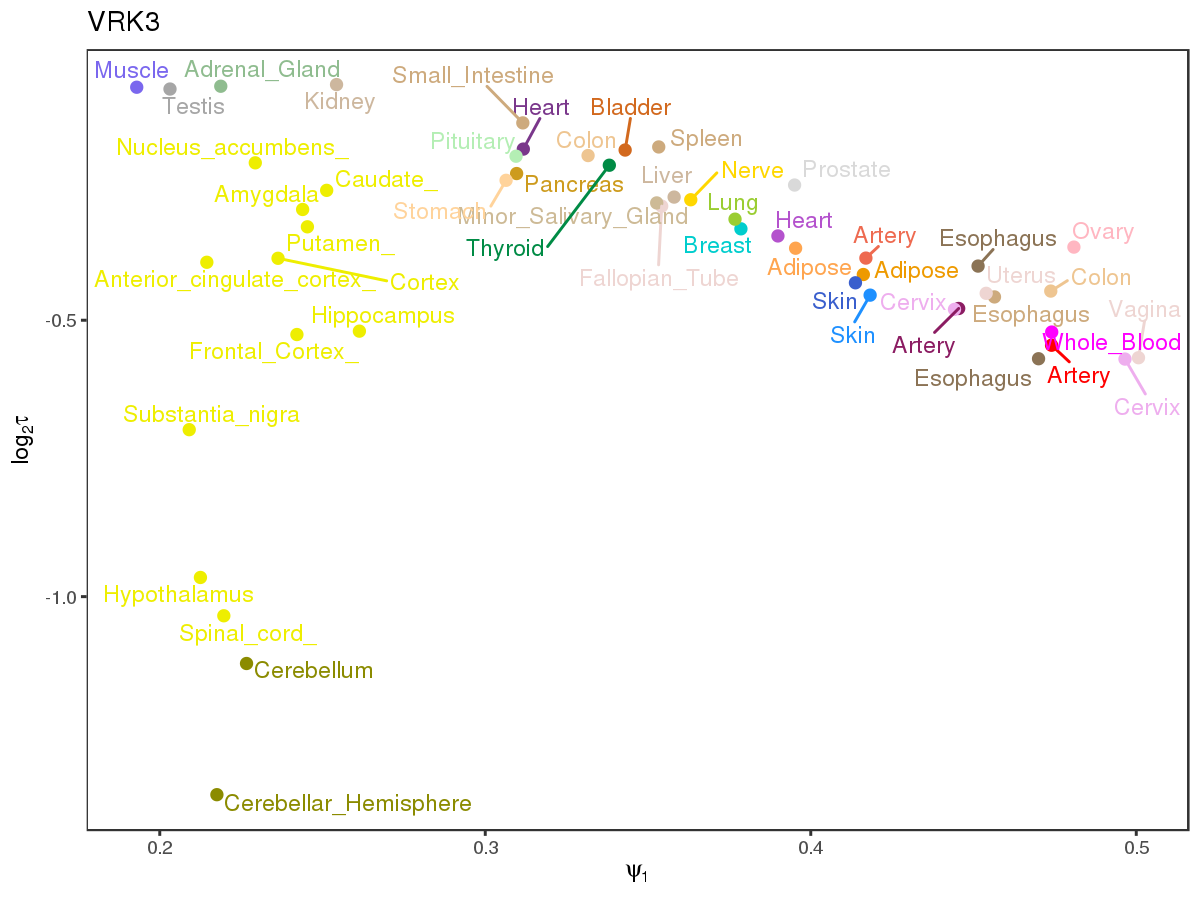

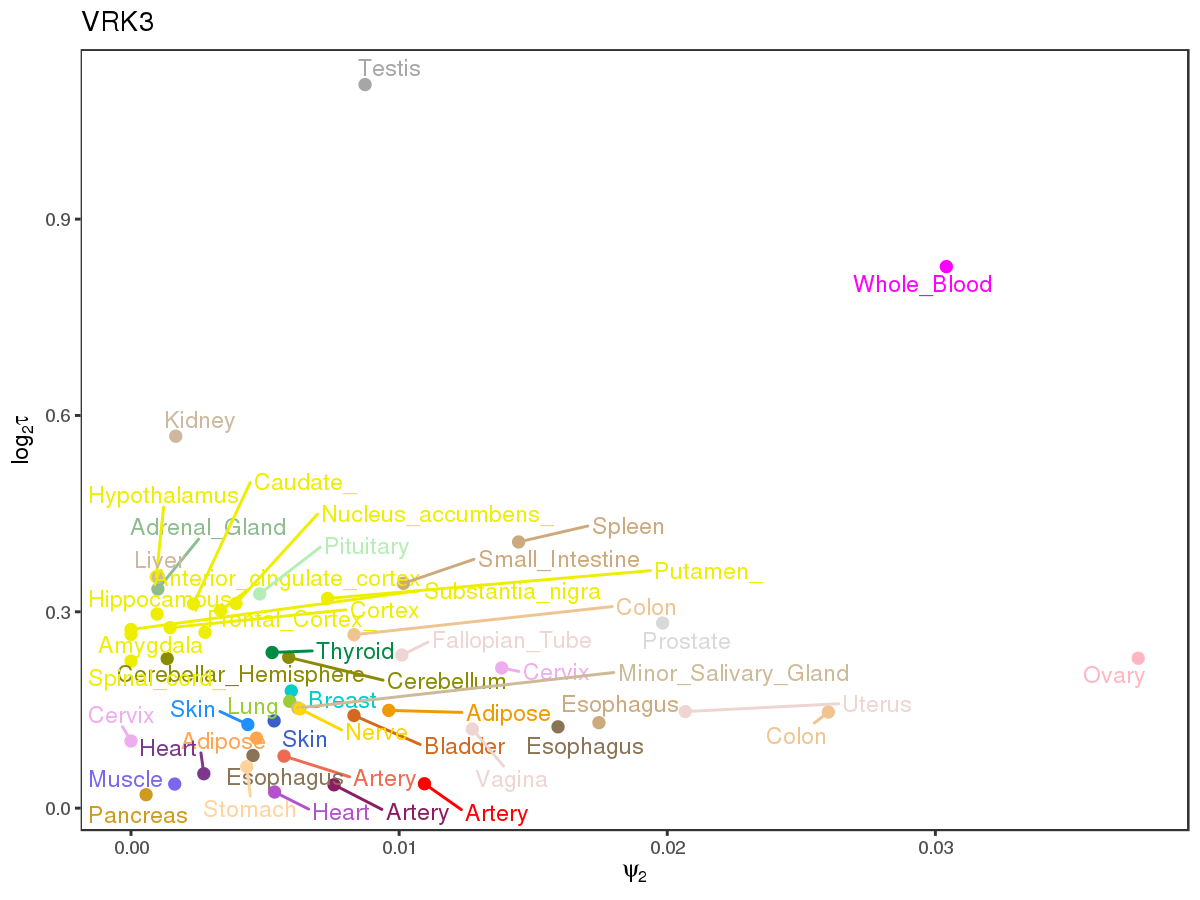

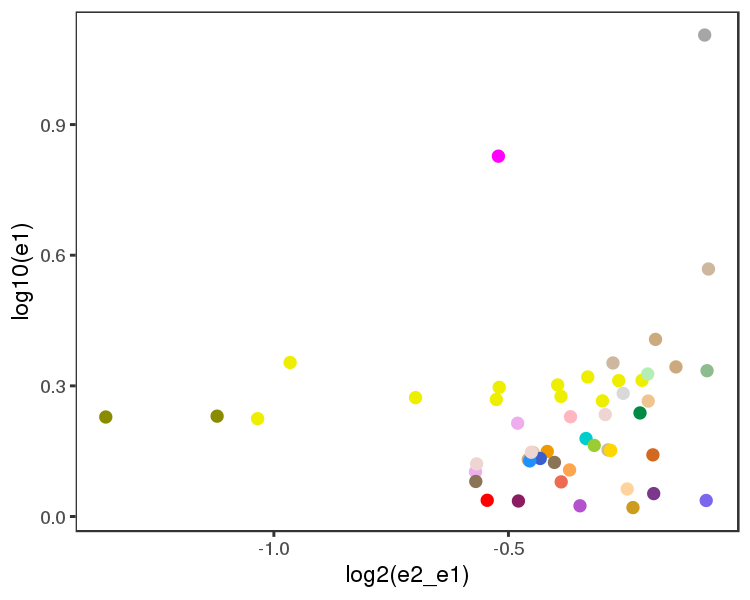

In [193]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 150)

gtex_filt_tis %>% 
filter(ex == cur_ex & E_junc == cur_Ejunc) %>% 
ggplot(aes(x = psi1, y = log2(e2_e1), color = tissue)) +
    geom_point(size=2) +
    geom_text_repel(aes(label = 
                        ifelse(grepl(tissue, pat = "Brain"),
                               str_split_fixed(tissue, pat = "[-\\(]", n = 3)[,2],
                               str_split_fixed(tissue, pat = "-", n = 2)[,1]))) +
    scale_color_manual(values = gtex_smtsd) +
    labs(y = TeX("$log_2 \\tau$"), x = TeX("$\\psi_1$"), title = cur_gene) +
    theme_blank +
    theme(legend.position = "none",
        legend.spacing.y = unit(-9, "pt")) 

gtex_filt_tis %>% 
filter(ex == cur_ex & E_junc == cur_Ejunc) %>% 
ggplot(aes(x = psi2, y = log10(e1), color = tissue)) +
    geom_point(size=2) +
    geom_text_repel(aes(label = 
                        ifelse(grepl(tissue, pat = "Brain"),
                               str_split_fixed(tissue, pat = "[-\\(]", n = 3)[,2],
                               str_split_fixed(tissue, pat = "-", n = 2)[,1]))) +
    scale_color_manual(values = gtex_smtsd) +
    labs(y = TeX("$log_2 \\tau$"), x = TeX("$\\psi_2$"), title = cur_gene) +
    theme_blank +
    theme(legend.position = "none",
        legend.spacing.y = unit(-9, "pt")) 

options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 150)

gtex_filt_tis %>% 
filter(ex == cur_ex & E_junc == cur_Ejunc) %>% 
ggplot(aes(x = log2(e2_e1), y = log10(e1), color = tissue)) +
    geom_point(size=2) +
    scale_color_manual(values = gtex_smtsd) +
    theme_blank +
    theme(legend.position = "none") 

In [226]:
(cur_tis <- cov_junc_tis_join %>% 
    dplyr::filter(ex == cur_ex & E_junc == cur_Ejunc) %>%   
    filter(!(
        grepl(tissue, pattern = "Cells") | #grepl(tissue, pattern = "Brain") |
        grepl(tissue, pattern = "Blood"))) %>% 
    filter(tpm >= 6 | is.na(tpm)) %>%
    mutate(smts = str_split_fixed(tissue,pattern = "-",n=2)[,1],
           psi1 = ifelse(I1 + E > 10, I1 / (I1 + E), NA),
           e2_e1 = ifelse(e1 > 0.1, e2 / e1, NA),
           n = n()) %>% 
    arrange(e2_e1) %>% 
    dplyr::filter(row_number() %in% c(1,2,3,4,n-3, n-2, n-1,n)) %>% 
    pull(tissue) )

[1] "Brain-Anterior_cingulate_cortex_(BA24)"
[2] "Brain-Frontal_Cortex_(BA9)"            
[3] "Ovary"                                 
[4] "Brain-Cortex"                          
[5] "Skin-Sun_Exposed_(Lower_leg)"          
[6] "Colon-Sigmoid"                         
[7] "Muscle-Skeletal"                       
[8] "Testis"

manually add tissues if needed

In [168]:
#cur_tis <- c("Pancreas","Skin-Sun_Exposed_(Lower_leg)","Brain-Cerebellum","Muscle-Skeletal")#[c(1,2,5,3,4)]
#cur_tis <- c("Bladder","Testis","Brain-Cerebellum","Pituitary","Thyroid")#[c(1,2,5,3,4)]
cur_tis <- c("Brain-Frontal_Cortex_(BA9)","Ovary",
             "Skin-Sun_Exposed_(Lower_leg)","Brain-Cerebellum","Colon-Sigmoid","Muscle-Skeletal")#[c(1,2,5,3,4)]

cur_tis <- c(cur_tis,"Brain-Cerebellum")
cur_tis <- cur_tis[c(1,2,3,4,9,8,5,6,7)]

### coverage tracks

In [169]:
bw_tracks <- lapply(
    cur_tis,
    function(cur_t){
        DataTrack(
            range = paste0("../../dplab/GTEX/coverage_SMTSD_GRCh38/", cur_t, ".bw"),
            name = gsub(gsub(gsub(
                        cur_t, pat = "_\\(.*\\)", rep = ""), pat = "-", rep = " "), pat = "_", rep = " "),
            #str_split_fixed(cur_t,pattern = "-",n=2)[2],
            col.axis = "black",
            window = -1, windowSize = as.integer((cur_to-cur_from)/200), 
            #stream=TRUE,
            lwd = 1.2,
            type = "polygon", lty.mountain = 0, lty.baseline = 0,
            fill.mountain = c("white", gtex_smtsd[cur_t]),
            alpha.title = 1, alpha = 1,
            from = cur_from - 100,to = cur_to + 100, chromosome = cur_chr)
       }
)

In [125]:
get_bw_lims <- function(bw_track, from, to, chromosome) {
    x <- Gviz::subset(bw_track, from = from, to = to, chromosome = chromosome)
    y <- as.numeric(values(x))
    y <- y[is.finite(y)]
 range(y)}

### junction tracks

In [170]:
names(cur_tis) <- cur_tis
tis_s <- lapply(
    cur_tis,
    function(tis){
        tis1 <- import.bed(
            con = BEDFile(paste0("/gss/mvlasenok/GTEX_SJ/J6_pertissue/", tis, ".bed")),
            extraCols = c(annotation = "integer", samples = "integer"),
            which = GRanges(seqnames = cur_chr, IRanges(cur_from + 150,cur_to - 150)))
        #tis1 <- tis1[tis1$score>=0.1*max(tis1$score)]
        mcols(tis1) <- data.frame(mcols(tis1),
                                  #"percent"=round(100*(mcols(tis1)$count/max_split)),
                                  "cigar" = paste0("10M", width(tis1), "N10M"), stringsAsFactors = FALSE)
        tis1 <- resize(tis1, width = width(tis1) + 10, fix = "center")
        return(tis1)
    }
)
max_split <- max(unlist(sapply(tis_s, function(x) x$score)))

In [171]:
#max(unlist(sapply(tis_s, function(x) x$score)))

[1] "Brain-Frontal_Cortex_(BA9)"   "Ovary"                       
[3] "Skin-Sun_Exposed_(Lower_leg)" "Brain-Cerebellum"            
[5] "Colon-Sigmoid"                "Muscle-Skeletal"

In [177]:
junc_track <- lapply(
    names(tis_s),
    function(n_tis){
        AlignmentsTrack(
            range = rep(tis_s[[n_tis]],
                        times = as.integer(tis_s[[n_tis]]$score)),
            sashimiStrand = as.character(cur_E[4]),
            name = "", #str_split_fixed(tis1$tissue[1],pattern = "-",n=2)[1],
            fontsize = 9,
            col = "black", col.sashimi = gtex_smtsd[n_tis],#"grey20",
            fill = "white", fontcolor = "black",
            type = c("sashimi"), col.axis = "transparent",
            lwd.sashimiMax = 7,
            #max(5*max(tis_s[[n_tis]]$score)/max_split,1),
                               #log2(1+max(tis_s[[n_tis]]$score)/max_split),
            sashimiScore = 20,#5*max(tis_s[[n_tis]]$score)/1000,
            #sashimiHeight=1000,
            sashimiNumbers = TRUE, genome = "hg38", 
            showAxis = FALSE, legend = FALSE,
            from = cur_from, to = cur_to, chromosome = cur_chr)
})

### annotation track

In [117]:
suppressPackageStartupMessages(library(GenomicFeatures))

In [118]:
chess_txdb <- loadDb("../references/chess3.1.3.GRCh38.txdb.sqlite")

In [173]:
txdb_track <- GeneRegionTrack(chess_txdb, 
                              chromosome = cur_chr, start = cur_from - 100, end = cur_to + 100,
                              strand = cur_str,
                              transcriptAnnotation = "", #symbol
                              stacking = "squish", name = paste("CHESS", cur_gene, sep = "\n"),
                              fill = 'black', col.line = 'black', col = "transparent",
                              lty = 1, min.height = 0.8, min.width = 1,
                              thinBoxFeature = c("utr", "utr3", "utr5"))

In [232]:
txdb_track

GeneRegionTrack 'CHESS
TM2D3'
| genome: NA
| active chromosome: chr15
| annotation features: 30

In [2]:
#manually specify if needed
transcripts_to_include <- c("CHS.57019.2","CHS.57019.17")
filt_range <- txdb_track@range[mcols(txdb_track@range)$transcript %in% transcripts_to_include]
txdb_track@range <- filt_range

ERROR: Error in eval(expr, envir, enclos): object 'txdb_track' not found


### PLOT

In [122]:
gat <- GenomeAxisTrack(exponent = 3, labelPos = "above", fontsize = 7, lwd = 1, distFromAxis = 0, scale=0.5)

#### TM2D3

In [184]:
junc_track_100 <- lapply(junc_track, function(jtr){
    displayPars(jtr) <- c(displayPars(jtr),list(sashimiScore=100))
    jtr})                          

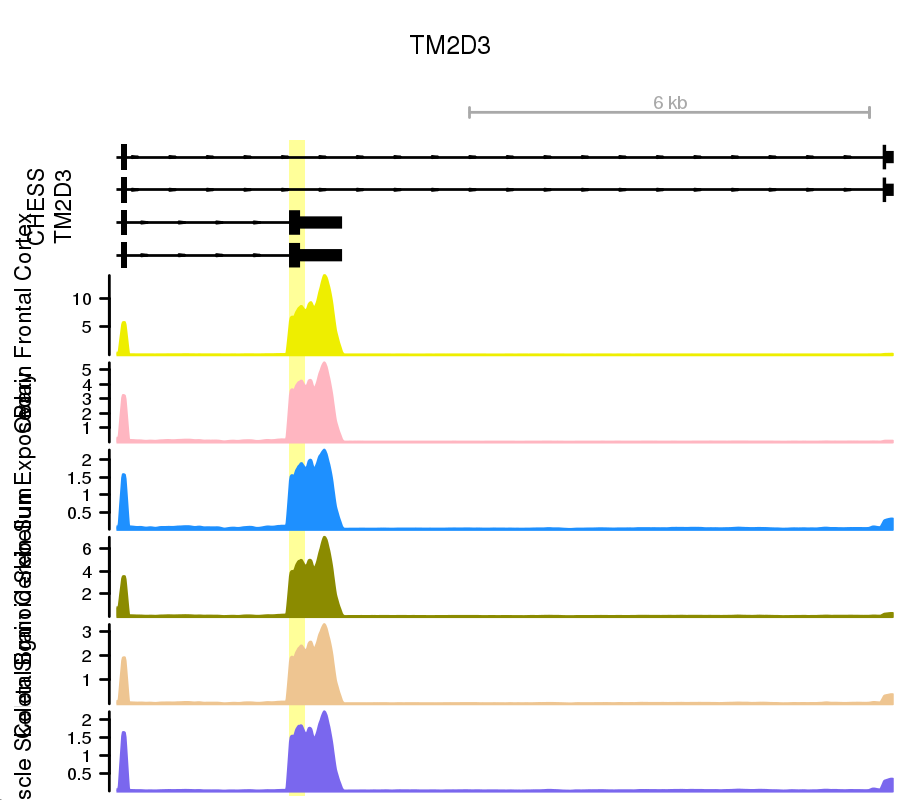

In [174]:
nopas_track <- HighlightTrack(
    trackList = c(txdb_track, bw_tracks),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)
    #seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))])

options(repr.plot.width = 4.5, repr.plot.height = 4, repr.plot.res = 200)

plotTracks(list(gat, nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = TRUE,
           sizes = c(0.65, 1.5, rep(1, length(bw_tracks))),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

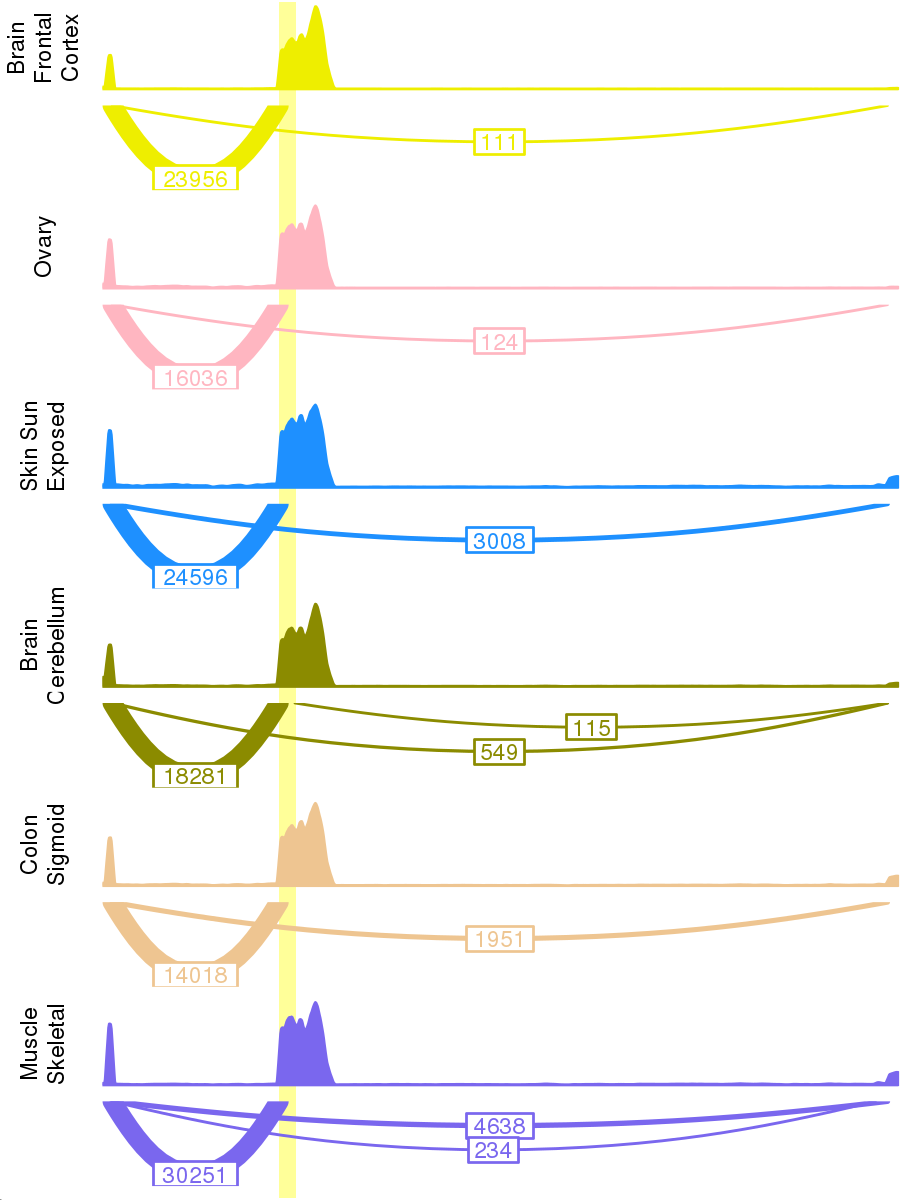

In [185]:
nopas_track <- HighlightTrack(
    trackList = c(
        c(bw_tracks, junc_track_100)[c(sapply(seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = length(cur_tis)*1, repr.plot.res = 200)

plotTracks(list(nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(rep(c(1, 1.2), length(cur_tis))),#background.width=0.2,
           #main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "), fontface.main = 1, cex.main = 0.75,
           margin = 1, innerMargin = 0,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

In [187]:
cur_set <- 1:4
lapply(bw_tracks, get_bw_lims, cur_from, cur_to, cur_chr)[cur_set]

[[1]]
[1]  0.000623 15.149643

[[2]]
[1] 0.001706 5.849081

[[3]]
[1] 0.004204 2.417801

[[4]]
[1] 0.006181 7.466348

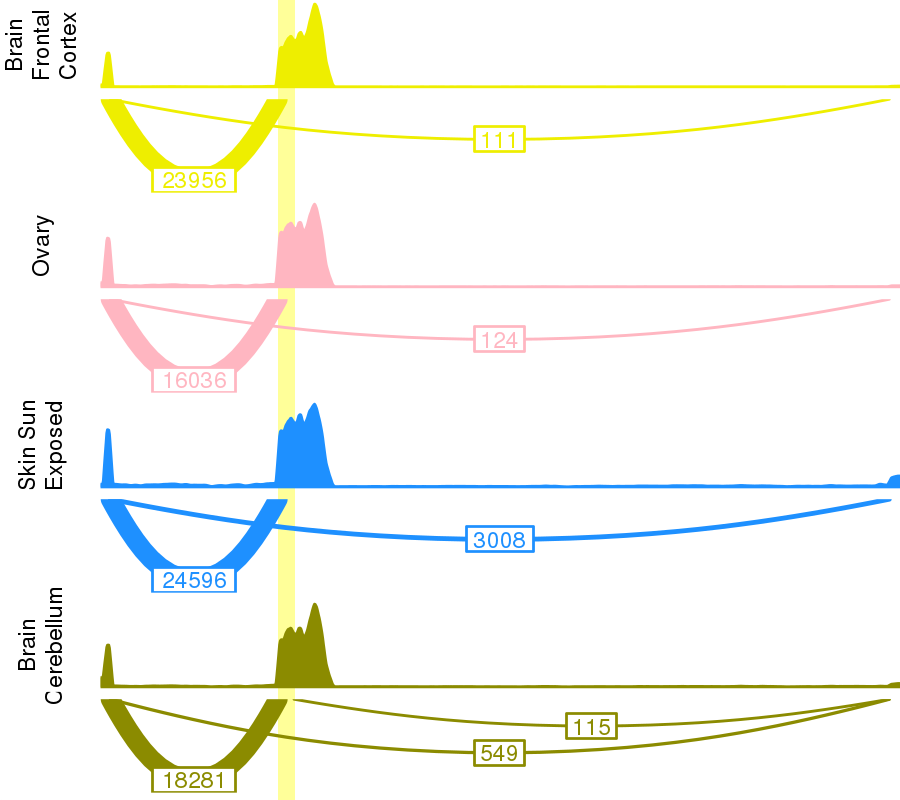

In [188]:
nopas_track <- HighlightTrack(
    trackList = c(
        c(bw_tracks, junc_track_100)[c(sapply(1:4, function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = 4, repr.plot.res = 200)

plotTracks(list(nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(rep(c(1, 1.2), 4)),#background.width=0.2,
           #main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "), fontface.main = 1, cex.main = 0.75,
           margin = 0, innerMargin = 0,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

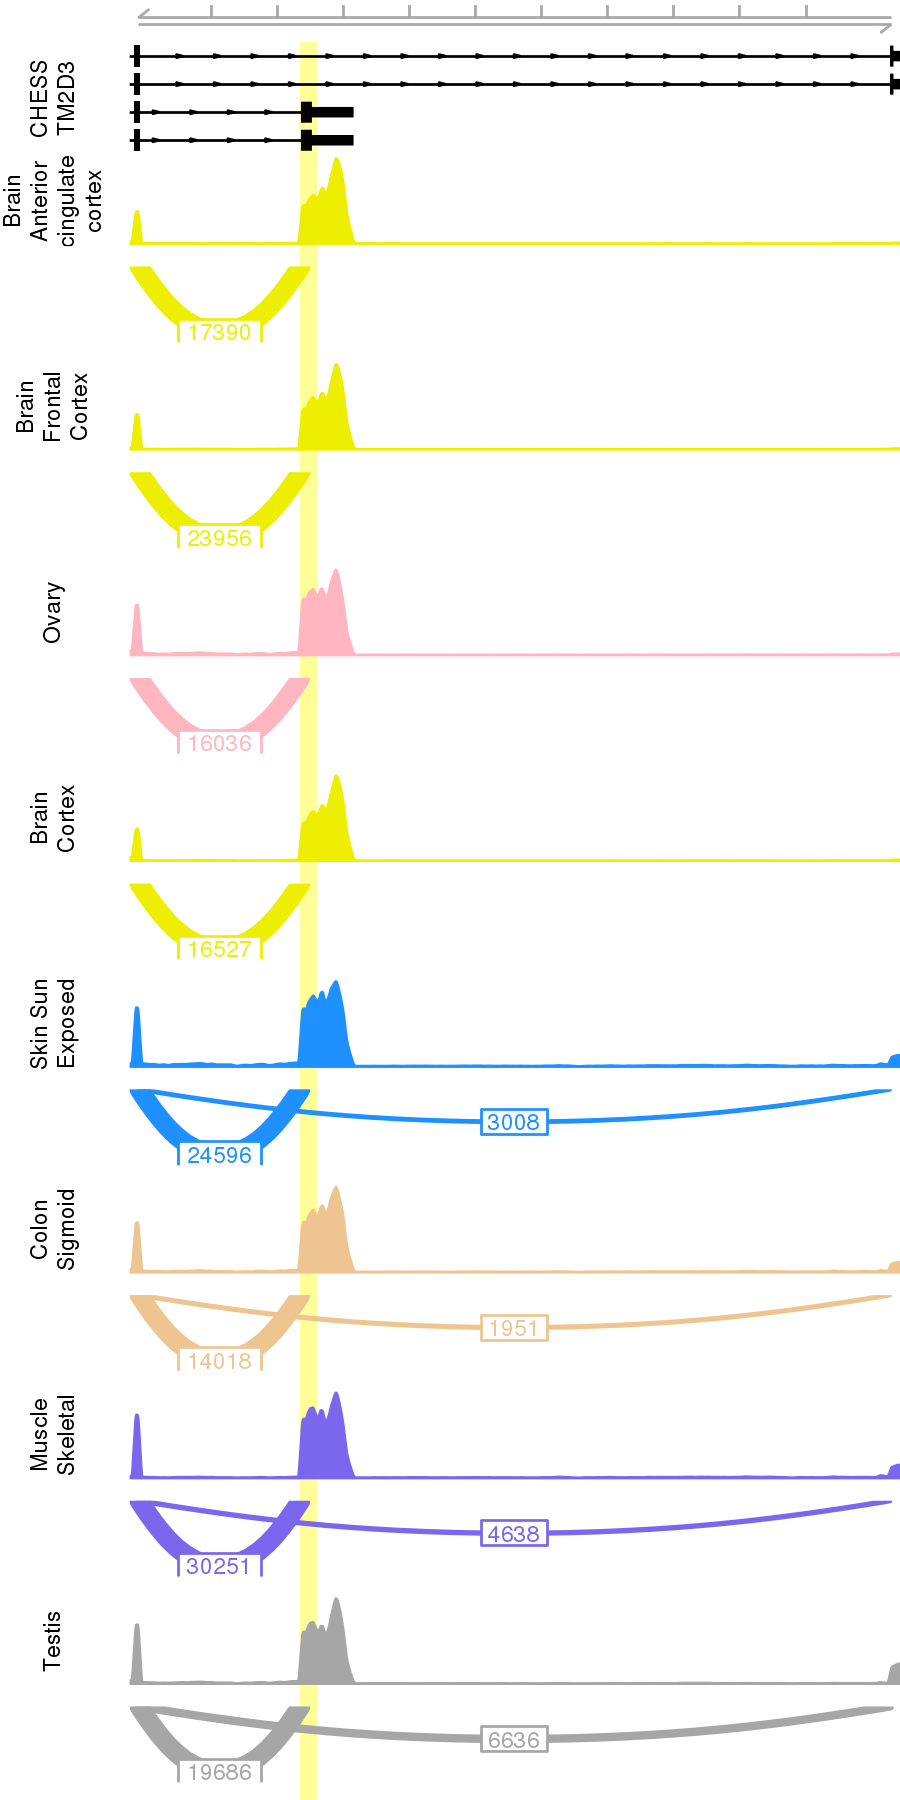

In [233]:
nopas_track <- HighlightTrack(
    trackList = c(
        txdb_track, 
        c(bw_tracks, junc_track)[c(sapply(seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = length(cur_tis)*1+1, repr.plot.res = 200)

plotTracks(list(gat, nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(0.45, 1.2, rep(c(1, 1.2), length(cur_tis))),#background.width=0.2,
           #main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "), fontface.main = 1, cex.main = 0.75,
           margin = 1, innerMargin = 0,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

#### DDX31 plots

In [150]:
lapply(bw_tracks, get_bw_lims, cur_from, cur_to, cur_chr)

[[1]]
[1] 0.000000 0.272669

[[2]]
[1] 0.000612 0.554529

[[3]]
[1] 0.001696 0.567529

[[4]]
[1] 0.000342 0.303119

[[5]]
[1] 0.000464 0.740677

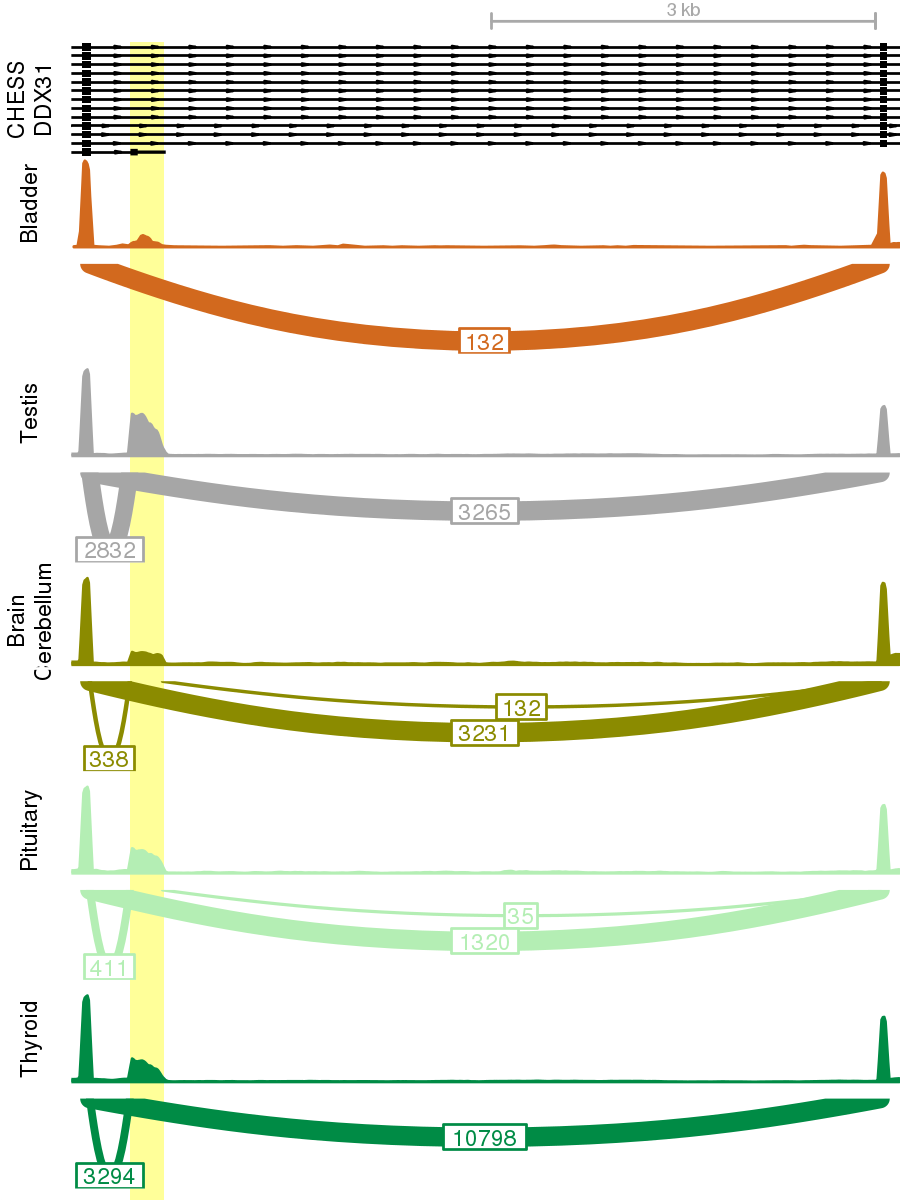

In [149]:
nopas_track <- HighlightTrack(
    trackList = c(
        txdb_track, 
        c(bw_tracks, junc_track)[c(sapply(seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = length(cur_tis)*1+1, repr.plot.res = 200)

plotTracks(list(gat, nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(0.45, 1.2, rep(c(1, 1.2), length(cur_tis))),#background.width=0.2,
           #main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "), fontface.main = 1, cex.main = 0.75,
           margin = 0, innerMargin = 0,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

In [151]:
cur_set <- c(1:3)
lapply(bw_tracks, get_bw_lims, cur_from, cur_to, cur_chr)[cur_set]

[[1]]
[1] 0.000000 0.272669

[[2]]
[1] 0.000612 0.554529

[[3]]
[1] 0.001696 0.567529

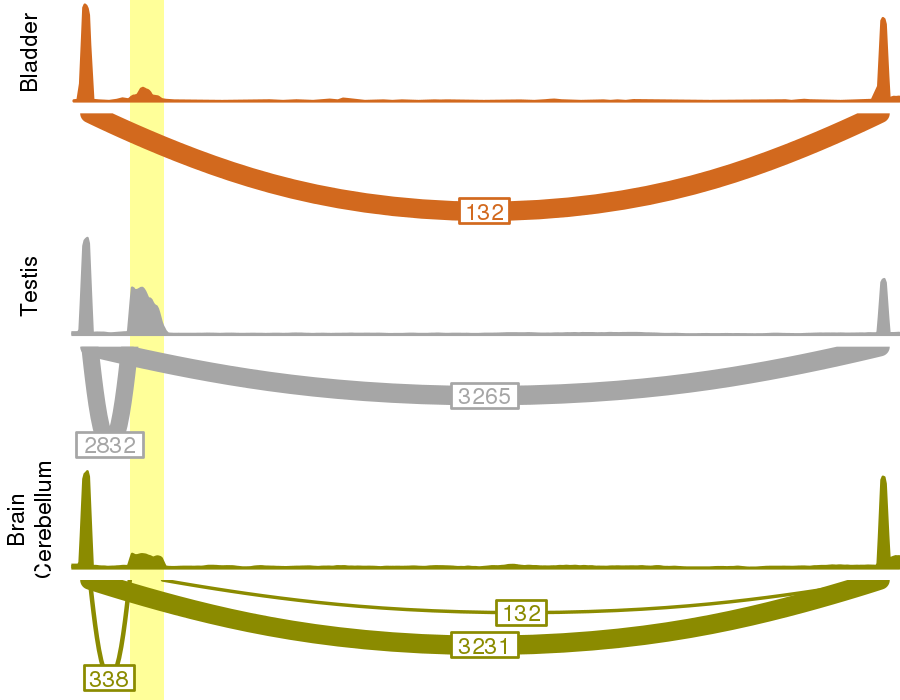

In [157]:
nopas_track <- HighlightTrack(
    trackList = c( 
        c(bw_tracks, junc_track)[c(sapply(cur_set, function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = 3.5, repr.plot.res = 200)

plotTracks(list(nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c( rep(c(1, 1.2), length(cur_set))),#background.width=0.2,
           #main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "), fontface.main = 1, cex.main = 0.75,
           margin = 0, innerMargin = 0,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

#### NFX1 plots

In [126]:
lapply(bw_tracks, get_bw_lims, cur_from, cur_to, cur_chr)

[[1]]
[1] 0.006278 0.813728

[[2]]
[1] 0.008134 3.052995

[[3]]
[1] 0.014954 2.463752

[[4]]
[1] 0.011099 2.091015

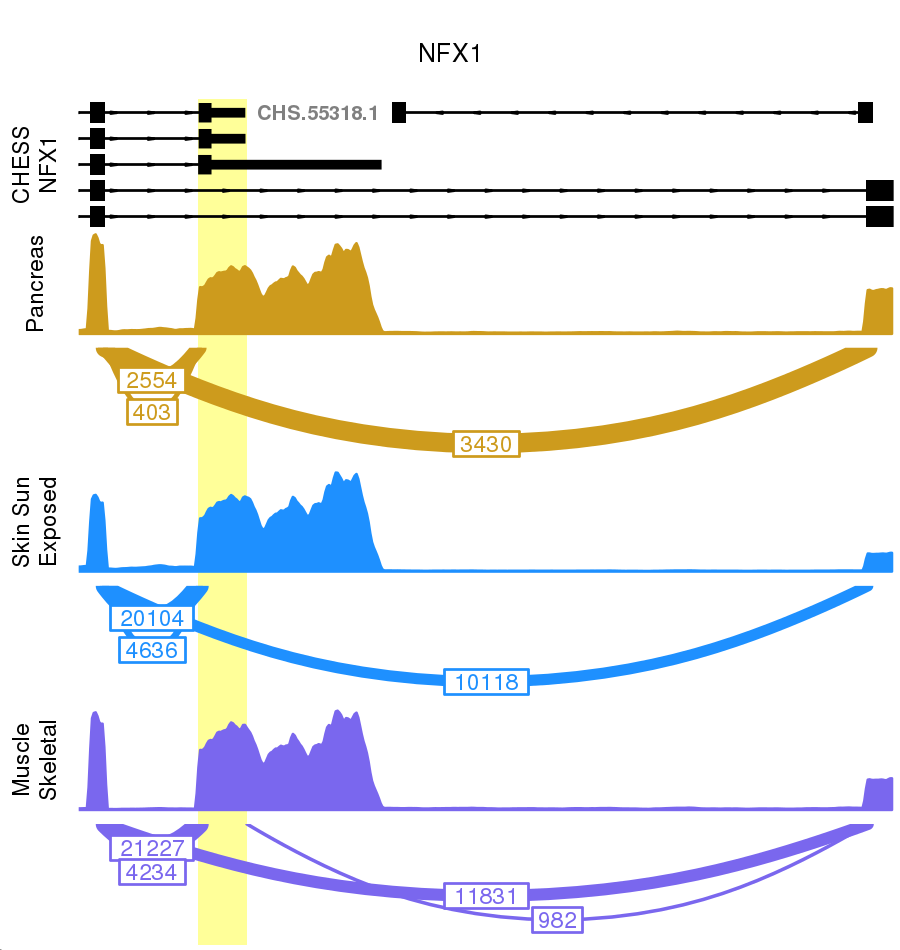

In [138]:
nopas_track <- HighlightTrack(
    trackList = c(
        txdb_track, 
        c(bw_tracks, junc_track)[c(sapply(c(1,2,4), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)
    #seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))])

options(repr.plot.width = 4.5, repr.plot.height = 4.75, repr.plot.res = 200)

plotTracks(list(nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(1.2, rep(c(1, 1.2), 3)),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

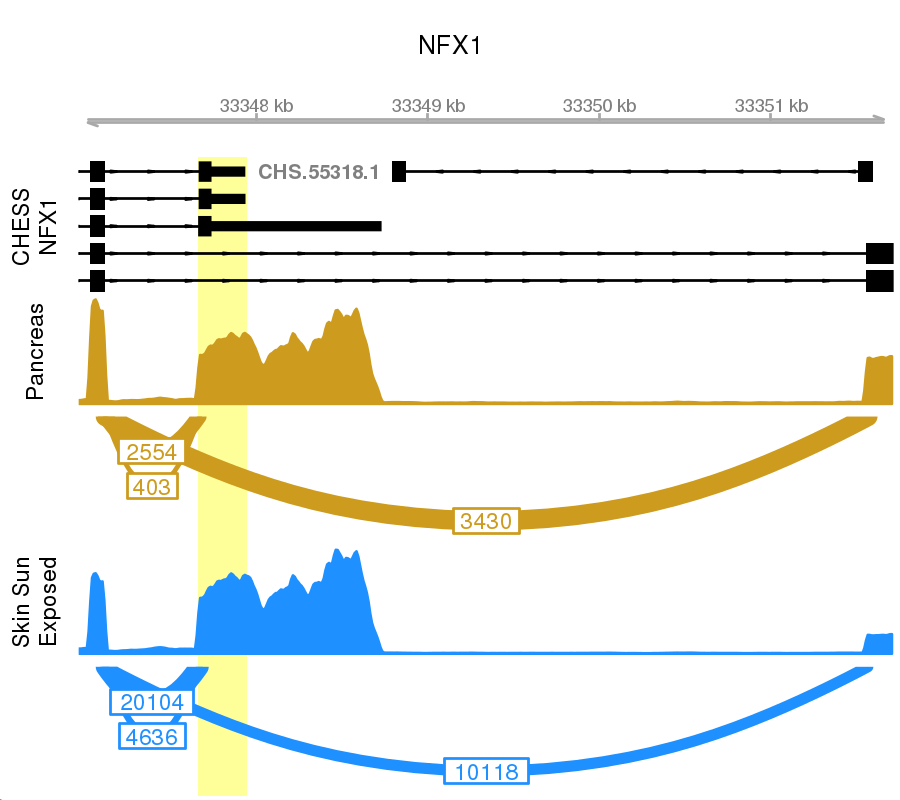

In [278]:
nopas_track <- HighlightTrack(
    trackList = c(
        txdb_track, 
        c(bw_tracks, junc_track)[c(sapply(c(3,1), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)
    #seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))])

options(repr.plot.width = 4.5, repr.plot.height = 4, repr.plot.res = 200)

plotTracks(list(gat, nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(0.65, 1.2, rep(c(1, 1.2), 2)),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

only bw with axis

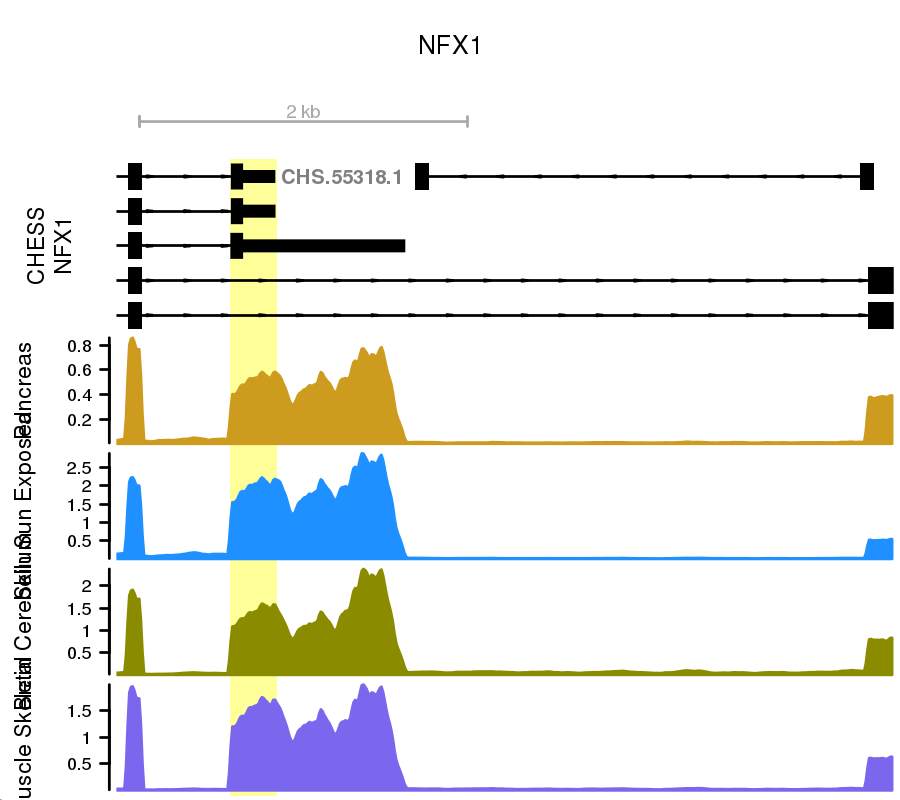

In [130]:
nopas_track <- HighlightTrack(
    trackList = c(txdb_track, bw_tracks[1:4]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)
    #seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))])

options(repr.plot.width = 4.5, repr.plot.height = 4, repr.plot.res = 200)

plotTracks(list(gat, nopas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = TRUE,
           sizes = c(0.65, 1.5, rep(1, 4)),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)

NMD tissues

In [154]:
lapply(bw_tracks_c, function(tr) displayPars(tr)$ylim)[c(1,5,6)]         

[[1]]
[1] 0.064569 2.114374

[[2]]
[1] 0.011099 1.809654

[[3]]
[1] 0.014954 1.796108

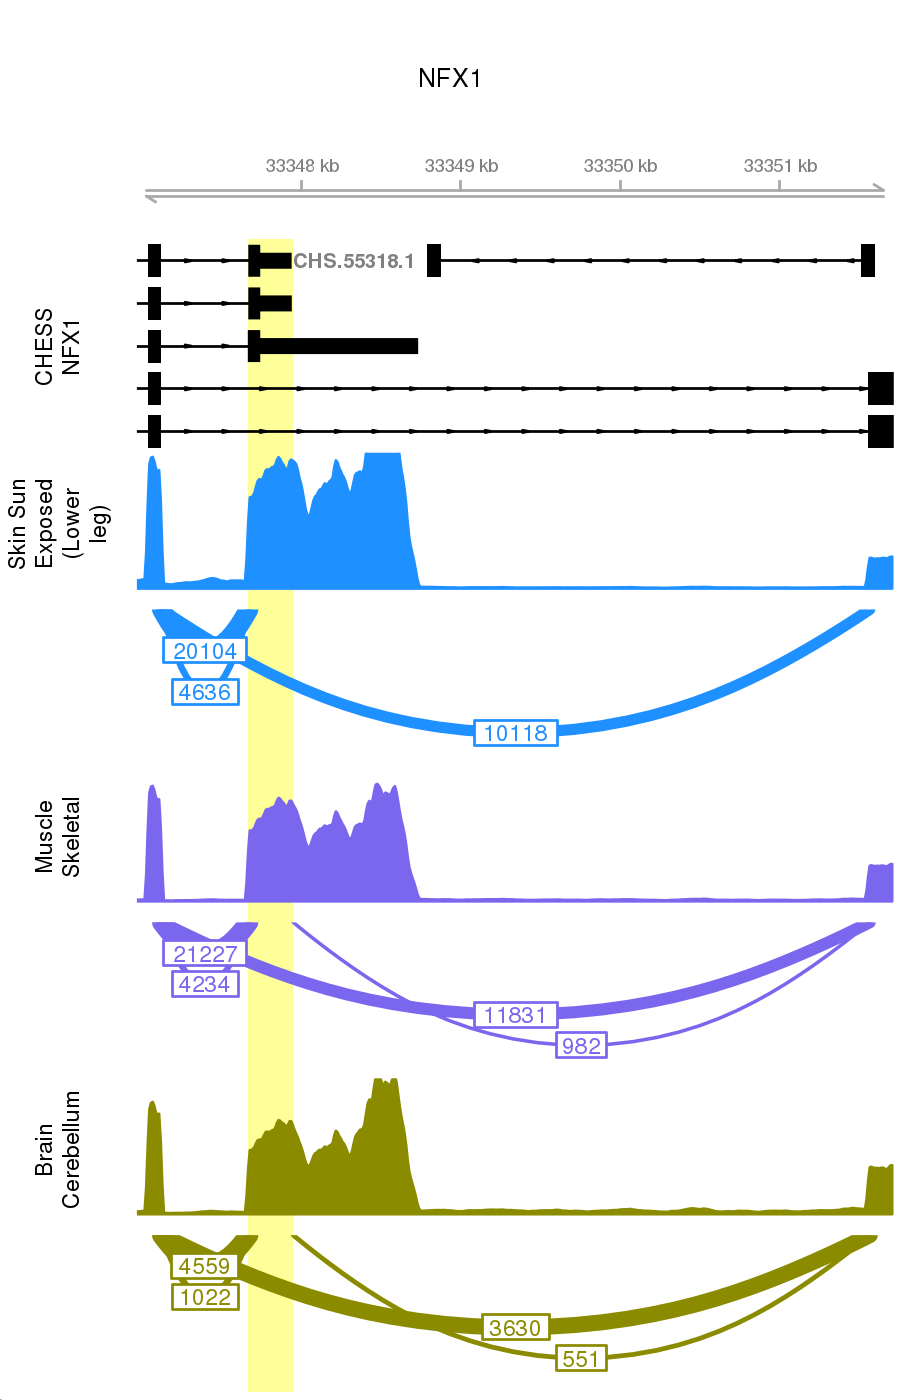

In [155]:
#1,5,6
nmd_track <- HighlightTrack(
    trackList = c(
        txdb_track, 
        c(bw_tracks_lim, junc_track)[c(sapply(c(1,5,6), function(x) c(x, x + length(cur_tis))))]),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)

options(repr.plot.width = 4.5, repr.plot.height = 7, repr.plot.res = 200)

plotTracks(list(gat, nmd_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(0.65, 1.5, rep(c(1, 1.2), 3)),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)                                   

### PAS track

In [226]:
pas_gr <- read.table("allPAS_w_chess.bed",head=T) %>% 
dplyr::filter(grepl(x = source, pat = "TE") | pAread >= 49 | atlas_exp >= 0.5) %>% GRanges(.) 

In [246]:
pas_inE <- subsetByOverlaps(pas_gr[with(mcols(pas_gr), pAread >= 100 | atlas_exp >= 0.5)],
                            GRanges(data.frame(cur_E)), ignore.strand=FALSE)
pas_track <- AnnotationTrack(pas_inE, name = "PAS", 
                             stackHeight = 1, 
                             groupAnnotation = "id", stacking = "squish",
                             just.group = "right",
                             cex.group = 0.6, fontcolor.group = "black", fontface.group = 1,
                             col = "transparent",
                             fill = ifelse(!is.na(pas_inE$transcript_id_te), "black", "grey70"),
                             shape = "box",
                             min.height = 3, collapse = TRUE)
identifier(pas_track) <- as.character(pas_inE$pAread)

[1] "1" "2" "3"

[1] "121"  "372"  "9192"

In [240]:
pas_track

AnnotationTrack 'PAS'
| genome: NA
| active chromosome: chr9
| annotation features: 4

In [247]:
wpas_track <- HighlightTrack(
    trackList = c(
        txdb_track,
        c(bw_tracks, junc_track)[c(sapply(seq_along(cur_tis), function(x) c(x, x + length(cur_tis))))],
        pas_track),
    start = str_split_fixed(cur_ex, pat = "_", n = 4)[2], 
    end = str_split_fixed(cur_ex, pat = "_", n = 4)[3],
    chromosome = cur_chr, 
    fill = "yellow", col = "transparent", alpha = 0.4)
    #start = ate_ex[ate_ex$ex==cur_ex,"TE",drop=T], width=2, chromosome = cur_chr, col="yellow")

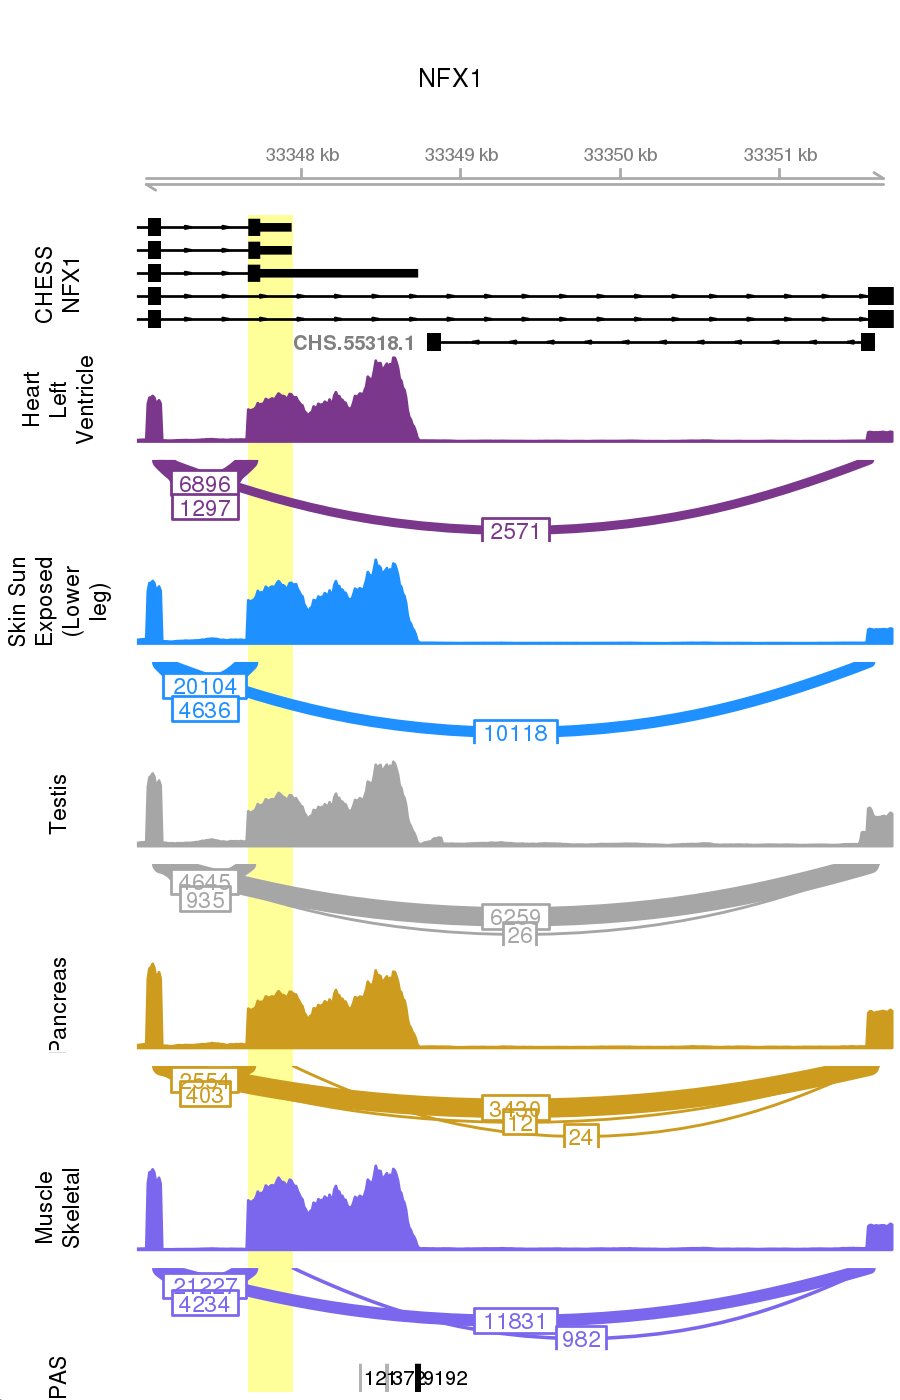

In [248]:
options(repr.plot.width = 4.5, repr.plot.height = 7, repr.plot.res = 200)

plotTracks(list(gat, wpas_track),
           fontsize = 8,
           reverseStrand = cur_str == "-",
           fontsize.title = 9, fontface.title = 1,
           col.title = "black", background.title = "transparent", cex.title = 0.9,
           cex.axis = 0.7, fontface.axis = 1,
           showAxis = FALSE,
           sizes = c(0.75, 1.5, rep(c(1, 1.2), length(cur_tis)),0.3),#background.width=0.2,
           main = cur_gene, gsub(cur_ex, pattern = "_", rep = " "),
           fontface.main = 1, cex.main = 0.75,
           margin = 3, innerMargin = 1,
           from = cur_from - 150, to = cur_to + 150, chromosome = cur_chr)